In [ ]:
!pip install pybaseball
!pip install catboost
!pip install scikit-learn==1.5.2
!pip install numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.9/375.9 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 856.7/856.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 91.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.0
    Uninstalling scikit-learn-1.6.0:
      Successfully uninstalled scikit-learn-1.6.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.1/356.1 kB 14.7 MB/s eta 0:00:00


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pybaseball import statcast

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor

from jax import random, vmap
import jax.numpy as jnp
from jax.scipy.special import logsumexp

import numpyro
from numpyro import handlers
from numpyro.diagnostics import hpdi
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
import arviz as az

import pickle

pl.Config(tbl_cols=1000)
pl.Config(tbl_rows=15)

# Training stuff model

In [ ]:
data_2021 = statcast('2021-04-01', '2021-10-03')
data_2022 = statcast('2022-04-07', '2022-10-02')
data_2023 = statcast('2023-03-30', '2023-10-01')
data = pd.concat([data_2021, data_2022, data_2023])
df = pl.DataFrame(data)
# get year
df = df.with_columns(
    year = df['game_date'].dt.year()
)

df = df.select('year', 'pitcher', 'player_name', 'p_throws', 'stand', 'pitch_type', 'release_speed', 'release_pos_x', 'release_pos_z', 'pfx_x', 'pfx_z', 'release_spin_rate', 'release_extension', 'spin_axis', 'delta_run_exp', 'arm_angle')
df = df.drop_nulls()
df = df.filter(~pl.col('pitch_type').is_in(['CS', 'PO', 'EP', 'KN', 'FA',]))

In [ ]:
# adjust lefties horz
df = df.with_columns(
    pl.when(pl.col('p_throws') == 'L')
    .then(pl.col('release_pos_x')*-1)
    .otherwise('release_pos_x')
    .alias('release_pos_x'),

    pl.when(pl.col('p_throws') == 'L')
    .then(pl.col('pfx_x')*-1)
    .otherwise('pfx_x')
    .alias('pfx_x'),

    pl.when(pl.col('p_throws')=='L')
    .then(360 - pl.col('spin_axis'))
    .otherwise(pl.col('spin_axis'))
    .alias('spin_axis')
)

# get most thrown fastball
pitch_count = (
    df
    .filter(pl.col('pitch_type').is_in(['FF', 'SI', 'FC']))
    .select('pitch_type', 'pitcher')
    .group_by('pitcher')
    .agg(
        pl.col('pitch_type')
        .mode()
        .first()
        .alias('primary_fastball')
    )
)
df = df.join(pitch_count, on='pitcher', how='left')

# get avg velo of most thrown fastball
fb_velo = (
    df
    .filter(pl.col('pitch_type') == pl.col('primary_fastball'))
    .select('pitcher', 'release_speed')
    .group_by('pitcher')
    .agg(
        pl.col('release_speed')
        .mean()
        .alias('primary_fb_speed')
    )
)
df = df.join(fb_velo, on='pitcher', how='left')

# get avg vert of most thrown fastball
fb_vert = (
    df
    .filter(pl.col('pitch_type') == pl.col('primary_fastball'))
    .select('pitcher', 'pfx_z')
    .group_by('pitcher')
    .agg(
        pl.col('pfx_z')
        .mean()
        .alias('primary_fb_vert')
    )
)
df = df.join(fb_vert, on='pitcher', how='left')

# get avg horz of most thrown fastball
fb_horz = (
    df
    .filter(pl.col('pitch_type') == pl.col('primary_fastball'))
    .select('pitcher', 'pfx_x')
    .group_by('pitcher')
    .agg(
        pl.col('pfx_x')
        .mean()
        .alias('primary_fb_horz')
    )
)
df = df.join(fb_horz, on='pitcher', how='left')

# get secondary pitch differences
df = df.with_columns(
    secondary_velo_differential = pl.when(pl.col('pitch_type').is_in(['FF', 'FC', 'SI']))
    .then(0)
    .otherwise(pl.col('primary_fb_speed') - pl.col('release_speed')),

    secondary_vert_differential = pl.when(pl.col('pitch_type').is_in(['FF', 'FC', 'SI']))
    .then(0)
    .otherwise(pl.col('primary_fb_vert') - pl.col('pfx_z')),

    secondary_horz_differential = pl.when(pl.col('pitch_type').is_in(['FF', 'FC', 'SI']))
    .then(0)
    .otherwise(pl.col('primary_fb_horz') - pl.col('pfx_x'))
)

# get same side
df = df.with_columns(
    pl.when(pl.col('p_throws')==pl.col('stand'))
    .then(1)
    .otherwise(0)
    .alias('same_side')
)

df = df.drop_nulls()

In [ ]:
# stuff model
feats = ['release_speed', 'release_pos_x', 'release_pos_z', 'release_extension', 'arm_angle', 'pfx_x', 'pfx_z', 'release_spin_rate', 'spin_axis', 'secondary_velo_differential', 'secondary_vert_differential', 'secondary_horz_differential', 'same_side']
target = 'delta_run_exp'

df_pandas = df.to_pandas()
X = df_pandas[feats]
X['same_side'] = X['same_side'].astype('category')
y = df_pandas[target]
model = CatBoostRegressor(
    cat_features = ['same_side'],
    loss_function = 'RMSE'
)
preds = cross_val_predict(model, X, y , cv=5, method='predict')

df = df.with_columns(pl.Series("run_exp_pred", preds))

<ipython-input-25-a34f17ec517c>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['same_side'] = X['same_side'].astype('category')


Streaming output truncated to the last 5000 lines.
4:	learn: 0.2409907	total: 2.7s	remaining: 8m 56s
5:	learn: 0.2409853	total: 2.98s	remaining: 8m 14s
6:	learn: 0.2409808	total: 3.23s	remaining: 7m 38s
7:	learn: 0.2409777	total: 3.46s	remaining: 7m 9s
8:	learn: 0.2409739	total: 3.69s	remaining: 6m 46s
9:	learn: 0.2409694	total: 3.93s	remaining: 6m 29s
10:	learn: 0.2409663	total: 4.17s	remaining: 6m 14s
11:	learn: 0.2409633	total: 4.39s	remaining: 6m 1s
12:	learn: 0.2409606	total: 4.63s	remaining: 5m 51s
13:	learn: 0.2409576	total: 4.87s	remaining: 5m 42s
14:	learn: 0.2409556	total: 5.11s	remaining: 5m 35s
15:	learn: 0.2409524	total: 5.36s	remaining: 5m 29s
16:	learn: 0.2409492	total: 5.58s	remaining: 5m 22s
17:	learn: 0.2409464	total: 5.83s	remaining: 5m 18s
18:	learn: 0.2409445	total: 6.06s	remaining: 5m 13s
19:	learn: 0.2409422	total: 6.29s	remaining: 5m 8s
20:	learn: 0.2409399	total: 6.52s	remaining: 5m 3s
21:	learn: 0.2409368	total: 6.75s	remaining: 4m 59s
22:	learn: 0.2409342	tot

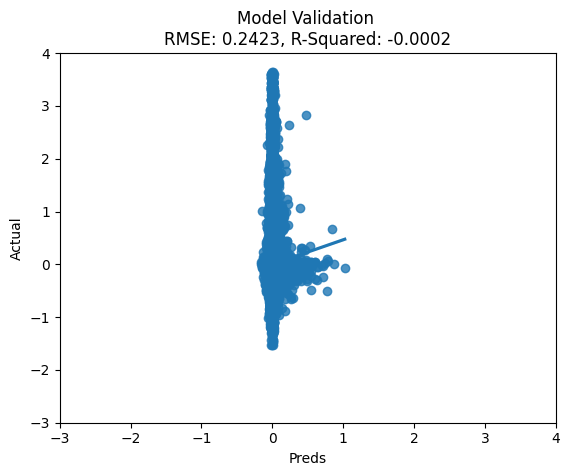

In [ ]:
r2 = (r2_score(y, preds))
rmse = np.sqrt(mean_squared_error(y, preds))

sns.regplot(data=df, x = 'run_exp_pred', y = 'delta_run_exp')
plt.xlabel('Preds')
plt.ylabel('Actual')
plt.title(f'Model Validation \nRMSE: {round(rmse, 4)}, R-Squared: {round(r2, 4)}')
plt.xlim([-3, 4])
plt.ylim([-3, 4])
plt.show()

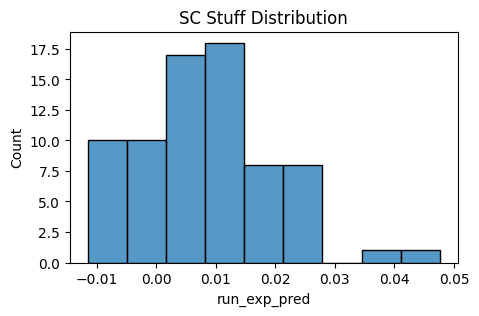

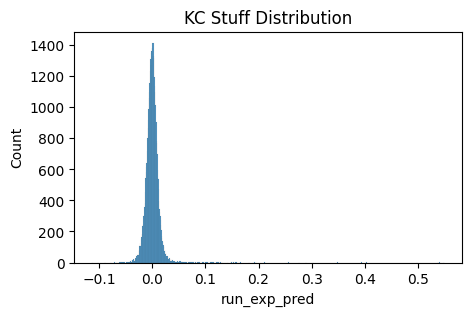

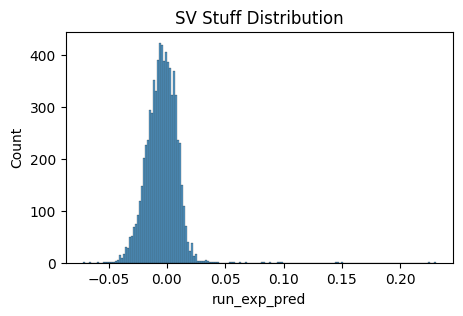

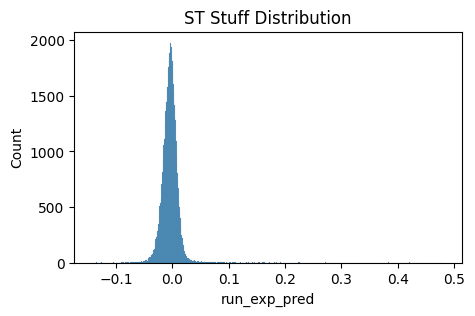

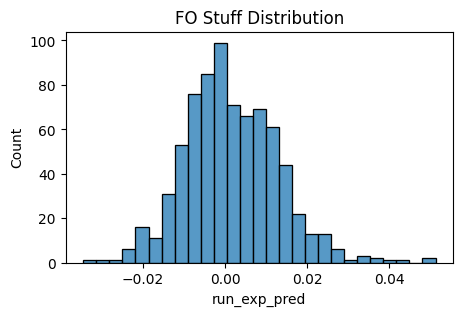

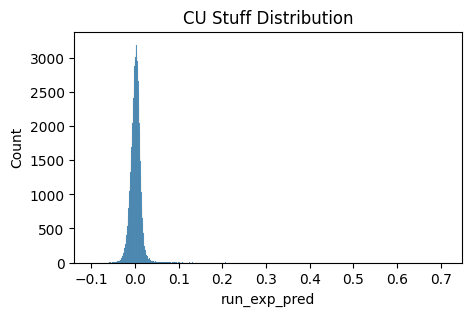

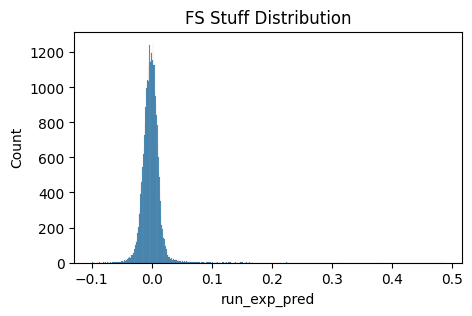

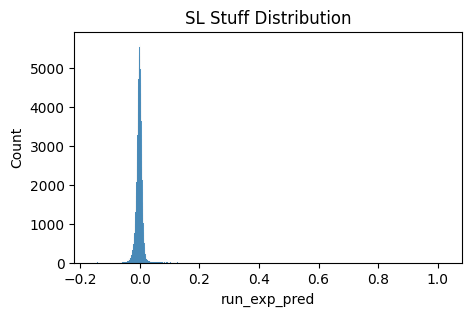

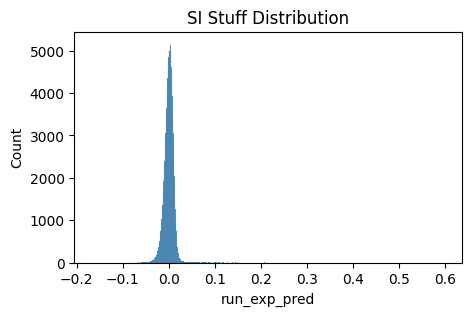

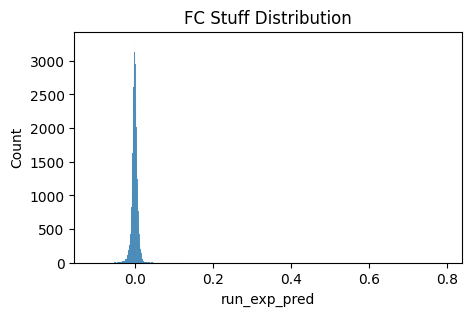

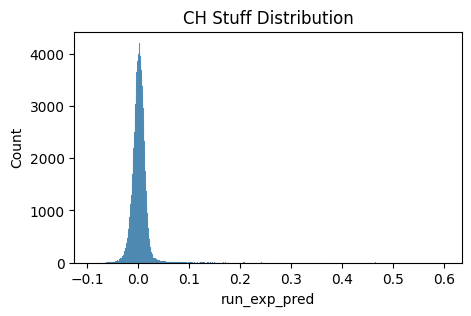

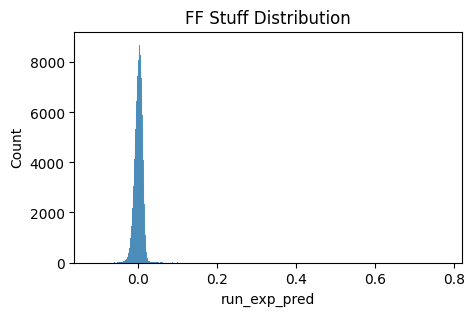

In [ ]:
for pitch in df['pitch_type'].unique():
    plt.figure(figsize = (5,3))
    sns.histplot(data = df.filter(pl.col('pitch_type') == pitch), x='run_exp_pred')
    plt.title(f'{pitch} Stuff Distribution')
    plt.show()

In [ ]:
# yearly pitch stuff
yearly_stuff_pitches = (df.select('year', 'pitcher', 'player_name', 'pitch_type', 'run_exp_pred')
.with_columns(pl.col("run_exp_pred").mean().over("year").alias('lg_avg_stuff'))
.group_by('year', 'pitcher', 'player_name', 'pitch_type', 'lg_avg_stuff')
.agg(
    pl.col('run_exp_pred')
    .mean()
    .alias('stuff')
)
.sort(by='stuff', descending=False)
)


current_year = yearly_stuff_pitches.with_columns(
    year = pl.col('year') - 1
)
current_year = current_year.select('year', 'pitcher', 'pitch_type', 'stuff').rename({'stuff':'stuff_next_yr'})

yearly_stuff_pitches = yearly_stuff_pitches.join(current_year, how='left', on=['year', 'pitcher', 'pitch_type'])

yearly_stuff_pitches = yearly_stuff_pitches.with_columns(
    (100 + (pl.col('stuff') - pl.col('lg_avg_stuff')).abs()/pl.col('lg_avg_stuff').abs()).alias("stuff+")
).sort(by='stuff', descending=False)

In [ ]:
# yearly avg stuff
yearly_stuff = (df.select('year', 'pitcher', 'player_name', 'run_exp_pred')
.with_columns(pl.col("run_exp_pred").mean().over("year").alias('lg_avg_stuff'))
.group_by('year', 'pitcher', 'player_name', 'lg_avg_stuff')
.agg(
    pl.col('run_exp_pred')
    .mean()
    .alias('stuff')
)
.sort(by='stuff', descending=False)
)


current_year = yearly_stuff.with_columns(
    year = pl.col('year') - 1
)
current_year = current_year.select('year', 'pitcher', 'stuff').rename({'stuff':'stuff_next_yr'})

yearly_stuff = yearly_stuff.join(current_year, how='left', on=['year', 'pitcher'])

yearly_stuff = yearly_stuff.with_columns(
    (100 + (pl.col('stuff') - pl.col('lg_avg_stuff')).abs()/pl.col('lg_avg_stuff').abs()).alias("stuff+")
).sort(by='stuff', descending=False)

In [ ]:
yearly_stuff.head()

year,pitcher,player_name,lg_avg_stuff,stuff,stuff_next_yr,stuff+
i64,i64,str,f64,f64,f64,f64
2023,689147,"""Kerkering, Orion""",-0.000397,-0.026867,null,166.618536
2023,642585,"""Bautista, Félix""",-0.000397,-0.025955,null,164.323555
2022,664126,"""Fairbanks, Pete""",-0.000133,-0.021007,-0.016884,257.073097
2022,642585,"""Bautista, Félix""",-0.000133,-0.019604,-0.025955,246.522261
2023,661403,"""Clase, Emmanuel""",-0.000397,-0.019352,null,147.705398


In [ ]:
yearly_stuff_pitches.head()

year,pitcher,player_name,pitch_type,lg_avg_stuff,stuff,stuff_next_yr,stuff+
i64,i64,str,str,f64,f64,f64,f64
2023,622098,"""Smith, Drew""","""SI""",-0.000397,-0.046573,null,216.213461
2021,663855,"""Hicks, Jordan""","""FF""",0.000988,-0.042146,-0.006034,143.660014
2022,664126,"""Fairbanks, Pete""","""CH""",-0.000133,-0.041217,0.007973,409.157006
2023,642585,"""Bautista, Félix""","""FF""",-0.000397,-0.034175,null,185.012267
2023,681987,"""Eaton, Nate""","""CH""",-0.000397,-0.033697,null,183.807943


In [ ]:
yearly_stuff_pitches.filter((pl.col('player_name') == 'deGrom, Jacob'))

year,pitcher,player_name,pitch_type,lg_avg_stuff,stuff,stuff_next_yr,stuff+
i64,i64,str,str,f64,f64,f64,f64
2021,594798,"""deGrom, Jacob""","""CH""",0.000988,-0.01497,0.000969,116.152981
2021,594798,"""deGrom, Jacob""","""CU""",0.000988,0.00533,-0.001659,104.39503
2021,594798,"""deGrom, Jacob""","""FF""",0.000988,-0.006255,-0.008268,107.331691
2021,594798,"""deGrom, Jacob""","""SL""",0.000988,-0.016649,-0.018383,117.851901
2022,594798,"""deGrom, Jacob""","""CH""",-0.000133,0.000969,-0.010062,108.294283
2022,594798,"""deGrom, Jacob""","""CU""",-0.000133,-0.001659,-0.001437,111.481893
2022,594798,"""deGrom, Jacob""","""FF""",-0.000133,-0.008268,-0.012277,161.214044
2022,594798,"""deGrom, Jacob""","""SL""",-0.000133,-0.018383,-0.016827,237.329795
2023,594798,"""deGrom, Jacob""","""CH""",-0.000397,-0.010062,null,124.323297


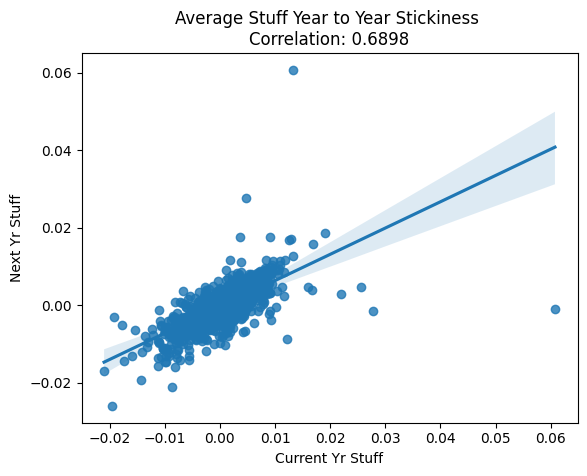

In [ ]:
# yty stuff stickiness plot
correlation = yearly_stuff.select(pl.corr('stuff', 'stuff_next_yr'))[0, 0]
sns.regplot(data=yearly_stuff, x='stuff', y='stuff_next_yr')
plt.ylabel('Next Yr Stuff')
plt.xlabel('Current Yr Stuff')
plt.title(f'Average Stuff Year to Year Stickiness \nCorrelation: {round(correlation, 4)}')
plt.show()

# Generating 2024 stuff preds

In [ ]:
# load in 2024 data

data_2024 = statcast('2024-03-28', '2024-09-29')
df_2024 = pl.DataFrame(data_2024)

df_2024 = df_2024.select('game_date', 'home_team', 'away_team', 'pitcher', 'player_name', 'p_throws', 'stand', 'inning', 'inning_topbot', 'outs_when_up', 'bat_score', 'events', 'post_bat_score', 'woba_value',
                         'pitch_type', 'release_speed', 'release_pos_x', 'release_pos_z', 'pfx_x', 'pfx_z', 'release_spin_rate', 'release_extension', 'spin_axis', 'delta_run_exp', 'arm_angle')
df_2024 = df_2024.drop_nulls()
df_2024 = df_2024.filter(~pl.col('pitch_type').is_in(['CS', 'PO', 'EP', 'KN', 'FA',]))

# adjust lefties horz
df_2024 = df_2024.with_columns(
    pl.when(pl.col('p_throws') == 'L')
    .then(pl.col('release_pos_x')*-1)
    .otherwise('release_pos_x')
    .alias('release_pos_x'),

    pl.when(pl.col('p_throws') == 'L')
    .then(pl.col('pfx_x')*-1)
    .otherwise('pfx_x')
    .alias('pfx_x'),

    pl.when(pl.col('p_throws')=='L')
    .then(360 - pl.col('spin_axis'))
    .otherwise(pl.col('spin_axis'))
    .alias('spin_axis')
)

# get most thrown fastball
pitch_count = (
    df_2024
    .filter(pl.col('pitch_type').is_in(['FF', 'SI', 'FC']))
    .select('pitch_type', 'pitcher')
    .group_by('pitcher')
    .agg(
        pl.col('pitch_type')
        .mode()
        .first()
        .alias('primary_fastball')
    )
)
df_2024 = df_2024.join(pitch_count, on='pitcher', how='left')

# get avg velo of most thrown fastball
fb_velo = (
    df_2024
    .filter(pl.col('pitch_type') == pl.col('primary_fastball'))
    .select('pitcher', 'release_speed')
    .group_by('pitcher')
    .agg(
        pl.col('release_speed')
        .mean()
        .alias('primary_fb_speed')
    )
)
df_2024 = df_2024.join(fb_velo, on='pitcher', how='left')

# get avg vert of most thrown fastball
fb_vert = (
    df_2024
    .filter(pl.col('pitch_type') == pl.col('primary_fastball'))
    .select('pitcher', 'pfx_z')
    .group_by('pitcher')
    .agg(
        pl.col('pfx_z')
        .mean()
        .alias('primary_fb_vert')
    )
)
df_2024 = df_2024.join(fb_vert, on='pitcher', how='left')

# get avg horz of most thrown fastball
fb_horz = (
    df_2024
    .filter(pl.col('pitch_type') == pl.col('primary_fastball'))
    .select('pitcher', 'pfx_x')
    .group_by('pitcher')
    .agg(
        pl.col('pfx_x')
        .mean()
        .alias('primary_fb_horz')
    )
)
df_2024 = df_2024.join(fb_horz, on='pitcher', how='left')

# get secondary pitch differences
df_2024 = df_2024.with_columns(
    secondary_velo_differential = pl.when(pl.col('pitch_type').is_in(['FF', 'FC', 'SI']))
    .then(0)
    .otherwise(pl.col('primary_fb_speed') - pl.col('release_speed')),

    secondary_vert_differential = pl.when(pl.col('pitch_type').is_in(['FF', 'FC', 'SI']))
    .then(0)
    .otherwise(pl.col('primary_fb_vert') - pl.col('pfx_z')),

    secondary_horz_differential = pl.when(pl.col('pitch_type').is_in(['FF', 'FC', 'SI']))
    .then(0)
    .otherwise(pl.col('primary_fb_horz') - pl.col('pfx_x'))
)

# get same side
df_2024 = df_2024.with_columns(
    pl.when(pl.col('p_throws')==pl.col('stand'))
    .then(1)
    .otherwise(0)
    .alias('same_side')
)

# date and game id cols
df_2024 = df_2024.with_columns(
     pl.col('game_date').dt.date().alias('date'),

     game_id = pl.col('game_date').dt.strftime("%Y%m%d") + pl.col('away_team') + 'at' + pl.col('home_team')
 )

df_2024 = df_2024.drop_nulls()

This is a large query, it may take a moment to complete


/usr/local/lib/python3.10/dist-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)
  0%|          | 0/186 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_co

In [ ]:
# stuff model for 2024

feats = ['release_speed', 'release_pos_x', 'release_pos_z', 'release_extension', 'arm_angle', 'pfx_x', 'pfx_z', 'release_spin_rate', 'spin_axis', 'secondary_velo_differential', 'secondary_vert_differential', 'secondary_horz_differential', 'same_side']
target = 'delta_run_exp'

df_pandas = df.to_pandas()
X = df_pandas[feats]
X['same_side'] = X['same_side'].astype('category')
y = df_pandas[target]
model = CatBoostRegressor(
    cat_features = ['same_side'],
    loss_function = 'RMSE'
)
model.fit(X, y)
df_pandas_2024 = df_2024.to_pandas()
preds = model.predict(df_pandas_2024[feats])

df_2024 = df_2024.with_columns(pl.Series("stuff", preds))

<ipython-input-5-ea6743202d26>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['same_side'] = X['same_side'].astype('category')


Learning rate set to 0.136854
0:	learn: 0.2422219	total: 533ms	remaining: 8m 52s
1:	learn: 0.2422127	total: 862ms	remaining: 7m 9s
2:	learn: 0.2422059	total: 1.19s	remaining: 6m 36s
3:	learn: 0.2422001	total: 1.52s	remaining: 6m 19s
4:	learn: 0.2421948	total: 1.83s	remaining: 6m 4s
5:	learn: 0.2421902	total: 2.14s	remaining: 5m 55s
6:	learn: 0.2421864	total: 2.46s	remaining: 5m 49s
7:	learn: 0.2421812	total: 2.79s	remaining: 5m 45s
8:	learn: 0.2421781	total: 3.08s	remaining: 5m 38s
9:	learn: 0.2421739	total: 3.37s	remaining: 5m 33s
10:	learn: 0.2421714	total: 3.7s	remaining: 5m 32s
11:	learn: 0.2421690	total: 4s	remaining: 5m 29s
12:	learn: 0.2421654	total: 4.31s	remaining: 5m 27s
13:	learn: 0.2421625	total: 4.64s	remaining: 5m 26s
14:	learn: 0.2421581	total: 4.94s	remaining: 5m 24s
15:	learn: 0.2421561	total: 5.22s	remaining: 5m 21s
16:	learn: 0.2421539	total: 5.59s	remaining: 5m 23s
17:	learn: 0.2421515	total: 6.09s	remaining: 5m 32s
18:	learn: 0.2421484	total: 6.67s	remaining: 5m 44

In [ ]:
# best stuff from 2024
(df_2024.select('pitcher', 'player_name', 'stuff')
.with_columns(pl.col("stuff").mean().alias('lg_avg_stuff'))
.group_by('pitcher', 'player_name', 'lg_avg_stuff')
.agg(
    pl.col('stuff')
    .mean()
    .alias('stuff')
)
.sort(by='stuff', descending=False)
).with_columns(
    (100 + (pl.col('stuff') - pl.col('lg_avg_stuff')).abs()/pl.col('lg_avg_stuff').abs()).alias("stuff+")
).sort(by='stuff', descending=False).head(10)

pitcher,player_name,lg_avg_stuff,stuff,stuff+
i64,str,f64,f64,f64
679885,"""Martinez, Justin""",-0.000198,-0.017443,187.034811
642528,"""Loáisiga, Jonathan""",-0.000198,-0.016784,183.705161
661403,"""Clase, Emmanuel""",-0.000198,-0.01674,183.485004
664854,"""Helsley, Ryan""",-0.000198,-0.016072,180.11577
608371,"""Sims, Lucas""",-0.000198,-0.015949,179.493049
687330,"""Kelly, Kevin""",-0.000198,-0.015068,175.046862
605280,"""Holmes, Clay""",-0.000198,-0.01424,170.869707
664126,"""Fairbanks, Pete""",-0.000198,-0.012882,164.016284
623352,"""Hader, Josh""",-0.000198,-0.012874,163.974739


In [ ]:
df_inning_stuff = (df_2024
 .select('game_id', 'date', 'pitcher', 'player_name', 'inning', 'stuff')
 .group_by('game_id', 'date', 'pitcher', 'player_name', 'inning')
 .agg(
     pl.col('stuff')
     .mean()
     .alias('avg_stuff')
 )
 ).sort(by=['date', 'pitcher', 'inning'])

In [ ]:
df_inning_results = (df_2024
 .select('game_id', 'date', 'pitcher', 'player_name', 'inning', 'inning_topbot', 'events', 'post_bat_score', 'bat_score', 'woba_value')
 .with_columns(
     outs = pl.when(pl.col('events').is_in(['triple_play']))
     .then(3)
     .when(pl.col('events').is_in(['sac_fly_double_play', 'grounded_into_double_play', 'strikeout_double_play', 'double_play']))
     .then(2)
     .when(pl.col('events').is_in(['fielders_choice_out', 'field_out', 'truncated_pa', 'force_out', 'strikeout', 'sac_fly', 'sac_bunt']))
     .then(1)
     .otherwise(0),

     runs = pl.col('post_bat_score') - pl.col('bat_score')
     )
 .select('game_id', 'date', 'pitcher', 'player_name', 'inning', 'inning_topbot', 'woba_value', 'outs', 'runs')
 .group_by('game_id', 'date', 'pitcher', 'player_name', 'inning', 'inning_topbot')
 .agg(
     pl.col('outs').sum().alias('outs'),
     pl.col('runs').sum().alias('runs'),
     pl.col('woba_value').mean().alias('avg_woba')
 )
 .unique(subset=['game_id', 'inning', 'inning_topbot'], keep='none') # drop inning with more than one pitcher
 .filter(pl.col('outs')==3) # drop innings where pitchers didnt get 3 outs
 ).select('game_id', 'date', 'pitcher', 'player_name', 'inning', 'runs', 'avg_woba').sort(by=['date', 'pitcher', 'inning'])

In [ ]:
df_innings = df_inning_stuff.join(df_inning_results, on = ['game_id', 'date', 'pitcher', 'player_name', 'inning'], how='inner')

In [ ]:
df_innings.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba
str,date,i64,str,i64,f64,i64,f64
"""20240328BOSatSEA""",2024-03-28,445276,"""Jansen, Kenley""",9,-0.003892,0,0.175
"""20240328BOSatSEA""",2024-03-28,455119,"""Martin, Chris""",8,-0.008354,0,0.3125
"""20240328CHCatTEX""",2024-03-28,489446,"""Yates, Kirby""",8,-0.002635,0,0.0
"""20240328CHCatTEX""",2024-03-28,502085,"""Robertson, David""",10,-0.010282,0,0.175
"""20240328SFatSD""",2024-03-28,506433,"""Darvish, Yu""",1,-0.005162,0,0.0


In [ ]:
from google.colab import files
df_innings.write_csv('df_innings.csv')
files.download('df_innings.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

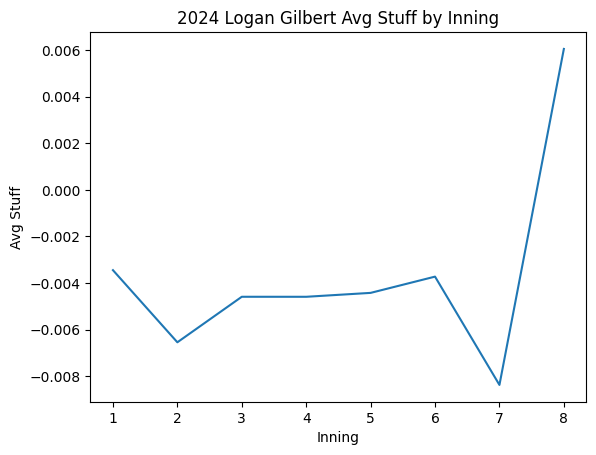

In [ ]:
_df = df_innings.filter(pl.col('player_name') == 'Gilbert, Logan').select('inning', 'avg_stuff').group_by('inning').agg(pl.col('avg_stuff').mean()).sort(by='inning')
sns.lineplot(data=_df, x='inning', y='avg_stuff')
plt.title('2024 Logan Gilbert Avg Stuff by Inning')
plt.ylabel('Avg Stuff')
plt.xlabel('Inning')
plt.show()

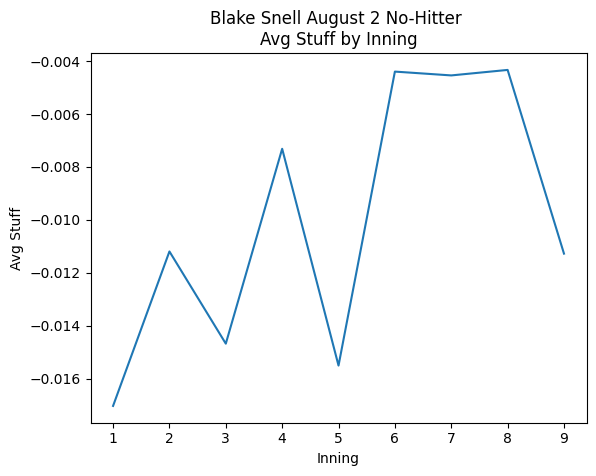

In [ ]:
_df = df_innings.filter((pl.col('player_name') == 'Snell, Blake') & (pl.col('game_id') == '20240802SFatCIN')).select('inning', 'avg_stuff').sort(by='inning')
sns.lineplot(data=_df, x='inning', y='avg_stuff')
plt.title('Blake Snell August 2 No-Hitter \nAvg Stuff by Inning')
plt.ylabel('Avg Stuff')
plt.xlabel('Inning')
plt.show()

# Predicting outings

In [ ]:
df_innings = pl.read_csv('/content/drive/MyDrive/Datasets/outing_predictions/df_innings.csv')

In [ ]:
df_innings.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba
str,str,i64,str,i64,f64,i64,f64
"""20240328BOSatSEA""","""2024-03-28""",445276,"""Jansen, Kenley""",9,-0.003892,0,0.175
"""20240328BOSatSEA""","""2024-03-28""",455119,"""Martin, Chris""",8,-0.008354,0,0.3125
"""20240328CHCatTEX""","""2024-03-28""",489446,"""Yates, Kirby""",8,-0.002635,0,0.0
"""20240328CHCatTEX""","""2024-03-28""",502085,"""Robertson, David""",10,-0.010282,0,0.175
"""20240328SFatSD""","""2024-03-28""",506433,"""Darvish, Yu""",1,-0.005162,0,0.0


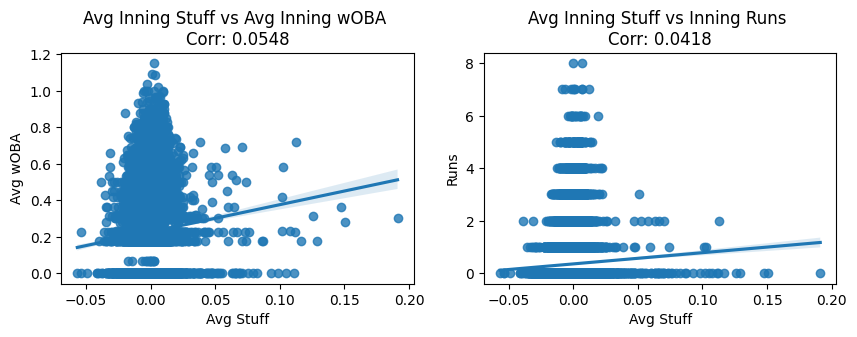

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

# stuff v woba stuff plot
correlation = df_innings.select(pl.corr('avg_stuff', 'avg_woba'))[0, 0]
sns.regplot(data=df_innings, x='avg_stuff', y='avg_woba', ax=ax1)
ax1.set_ylabel('Avg wOBA')
ax1.set_xlabel('Avg Stuff')
ax1.set_title(f'Avg Inning Stuff vs Avg Inning wOBA \nCorr: {round(correlation, 4)}')

# stuff v woba stuff plot
correlation = df_innings.select(pl.corr('avg_stuff', 'runs'))[0, 0]
sns.regplot(data=df_innings, x='avg_stuff', y='runs', ax=ax2)
ax2.set_ylabel('Runs')
ax2.set_xlabel('Avg Stuff')
ax2.set_title(f'Avg Inning Stuff vs Inning Runs \nCorr: {round(correlation, 4)}')

plt.show()

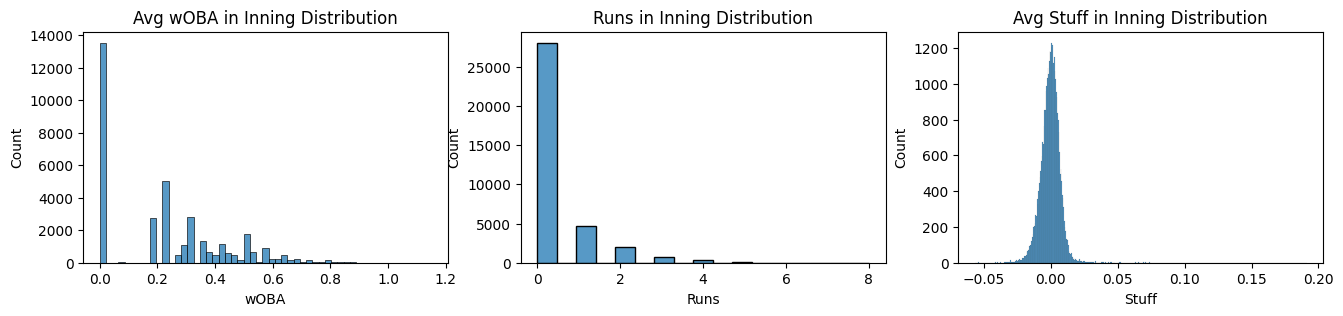

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16, 3))

sns.histplot(data=df_innings, x='avg_woba', ax = ax1)
ax1.set_xlabel('wOBA')
ax1.set_title('Avg wOBA in Inning Distribution')

sns.histplot(data=df_innings, x='runs', ax=ax2)
ax2.set_xlabel('Runs')
ax2.set_title('Runs in Inning Distribution')

sns.histplot(data=df_innings, x='avg_stuff', ax=ax3)
ax3.set_xlabel('Stuff')
ax3.set_title('Avg Stuff in Inning Distribution')

plt.show()

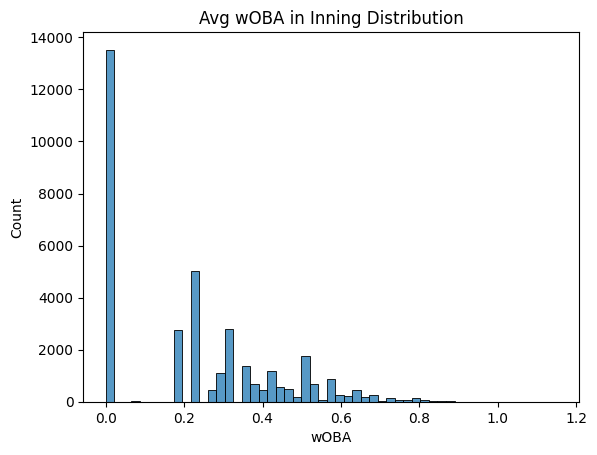

In [ ]:
sns.histplot(data=df_innings, x='avg_woba')
plt.xlabel('wOBA')
plt.title('Avg wOBA in Inning Distribution')

plt.show()

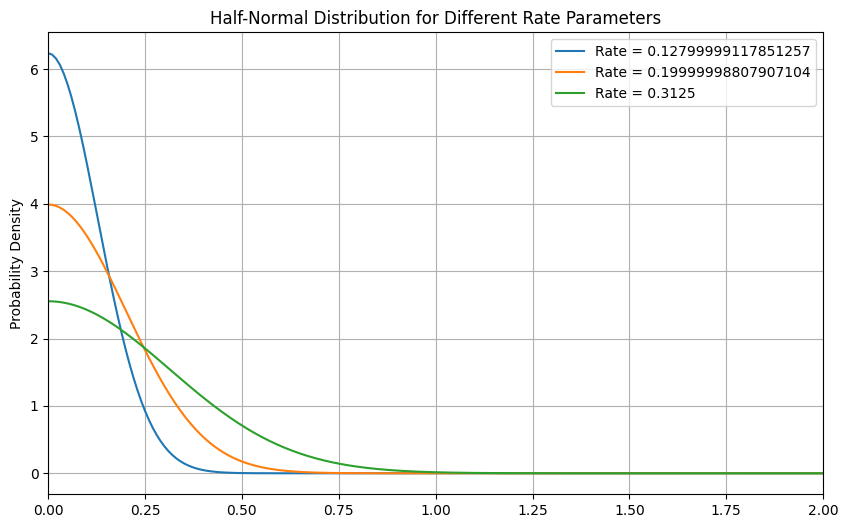

In [ ]:
# seeing whats a reasonable prior for the intercept
import scipy.stats as stats

def plot_half_normal(rate_values):
    x = np.linspace(0, 10, 1000)

    plt.figure(figsize=(10, 6))

    for rate in rate_values:
        y = stats.halfnorm.pdf(x, scale=rate)
        plt.plot(x, y, label=f'Rate = {rate}')

    plt.title('Half-Normal Distribution for Different Rate Parameters')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.xlim([0, 2])
    plt.show()

rate_values = [jnp.exp(np.log(0.2) - (2*np.log(1.25))), jnp.exp(np.log(0.2)), jnp.exp(np.log(0.2) + (2*np.log(1.25)))]
plot_half_normal(rate_values)

In [ ]:
# half normal model
def woba_model(stuff = None, woba = None):
    # intercept prior on the log scale
    a = numpyro.sample('a', dist.Normal(np.log(0.2), np.log(1.25)))

    S = 0.0
    if stuff is not None:
        # stuff prior
        bS = numpyro.sample('bS', dist.Normal(25, 25))
        S = bS * stuff

    # model the rate for the likelihood function
    rate = numpyro.deterministic('rate', jnp.exp(a + S)) # as S increases/decreases so does runs
    rate = jnp.where(rate > 2, 2, rate) # to prevent unrealistic wobas in like 0.1% of outcomes

    # likelihood function
    numpyro.sample('obs', dist.HalfNormal(rate), obs = woba)

In [ ]:
rng_key = random.key(0)
rng_key, rng_key1 = random.split(rng_key)

In [ ]:
# simulating the prior
prior_predictive = Predictive(woba_model, num_samples = 100)
stuff_jax = jnp.array(df_innings.select(pl.col('avg_stuff')).to_numpy())
prior_predictions = prior_predictive(rng_key1, stuff = stuff_jax)['obs']
mean_prior_pred = jnp.mean(prior_predictions, axis=0)

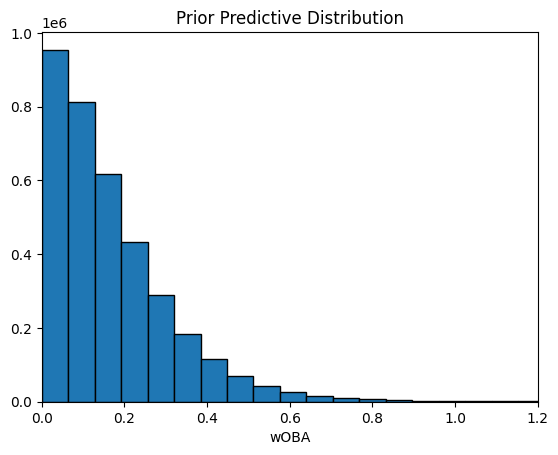

In [ ]:
# prior predictive distribution
numpy_array = np.array(prior_predictions).flatten()

plt.hist(numpy_array, bins=100, edgecolor='black')
plt.title("Prior Predictive Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

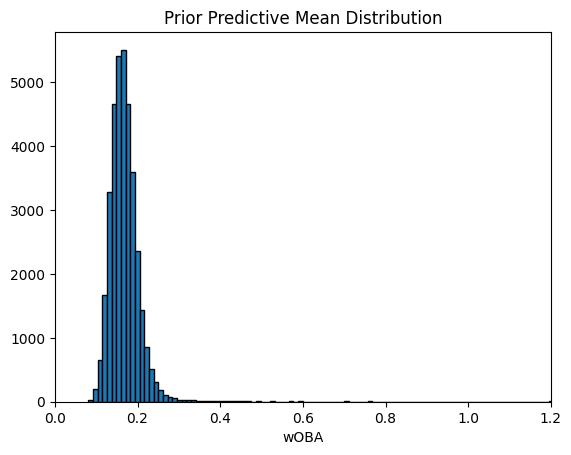

In [ ]:
# prior predictive mean distribution
numpy_array = np.array(mean_prior_pred)

plt.hist(numpy_array, bins=100, edgecolor='black')
plt.title("Prior Predictive Mean Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

In [ ]:
# running inference
kernel = NUTS(woba_model)

rng_keys = random.split(rng_key, 4)
woba_jax = jnp.array(df_innings.select(pl.col('avg_woba')).to_numpy())

mcmc = MCMC(kernel, num_warmup = 1000, num_samples = 2000, num_chains = 4)
mcmc.run(
    rng_keys, stuff = stuff_jax, woba = woba_jax
)
mcmc.print_summary()

<ipython-input-9-08b883e0f1ef>:6: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup = 1000, num_samples = 2000, num_chains = 4)
sample: 100%|██████████| 3000/3000 [00:17<00:00, 166.96it/s, 7 steps of size 7.02e-01. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -1.17      0.00     -1.17     -1.17     -1.16   7135.06      1.00
        bS      6.01      0.55      6.02      5.12      6.94   4442.73      1.00

Number of divergences: 0


In [ ]:
with open('/content/drive/MyDrive/Datasets/outing_predictions/mcmc_model.pkl', 'wb') as file:
    pickle.dump(mcmc, file)

In [ ]:
with open('/content/drive/MyDrive/Datasets/outing_predictions/mcmc_model.pkl', 'rb') as f:
    mcmc = pickle.load(f)

In [ ]:
posterior_samples = mcmc.get_samples()

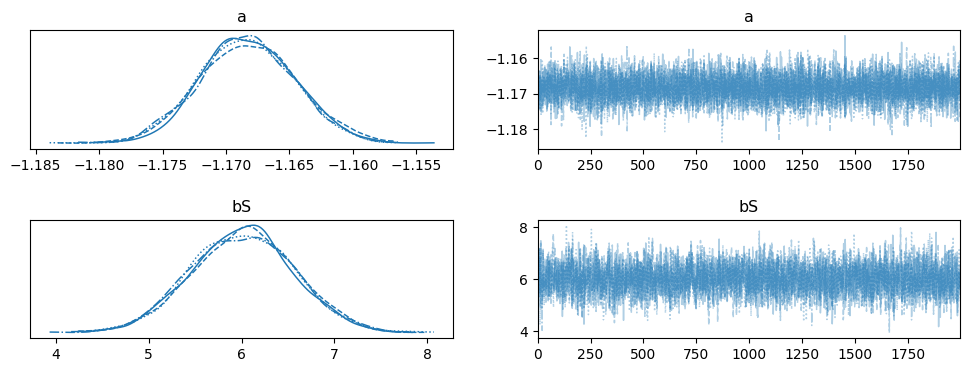

In [ ]:
# trace plots
data = az.from_numpyro(mcmc)

az.plot_trace(data, var_names = ['a', 'bS'], compact = True)
plt.subplots_adjust(hspace = 0.6)
plt.show()

In [ ]:
# prediction functions
def predict(rng_key, post_samples, model, *args, **kwargs):
    model = handlers.seed(handlers.condition(woba_model, post_samples), rng_key)
    model_trace = handlers.trace(model).get_trace(*args, **kwargs)
    return model_trace["obs"]["value"]

predict_fn = vmap(
    lambda rng_key, samples: predict(
        rng_key, samples, woba_model, stuff = stuff_jax
    )
)

In [ ]:
# make posterior preds
rng_key, rng_key1 = random.split(rng_key)

predictions_1 = predict_fn(random.split(rng_key1, 8000), posterior_samples)

mean_pred = jnp.mean(predictions_1, axis=0)
numpy_mean_pred = np.array(mean_pred).flatten()
df_innings = df_innings.with_columns(
    mean_predictions = numpy_mean_pred
)

In [ ]:
df_innings.sort(by='avg_woba', descending = True).head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240831LADatAZ""","""2024-08-31""",518876,"""Kelly, Merrill""",1,0.002708,3,1.15,0.250873
"""20240911CHCatLAD""","""2024-09-11""",696136,"""Wicks, Jordan""",1,0.000969,5,1.088889,0.251851
"""20240510ATLatNYM""","""2024-05-10""",500779,"""Quintana, Jose""",3,0.003451,4,1.085714,0.254022
"""20240426PHIatSD""","""2024-04-26""",605397,"""Musgrove, Joe""",3,-0.0027,4,1.035714,0.244533
"""20240802AZatPIT""","""2024-08-02""",682847,"""Ortiz, Luis L.""",1,0.005896,5,1.022222,0.258811


In [ ]:
df_innings.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240328BOSatSEA""","""2024-03-28""",445276,"""Jansen, Kenley""",9,-0.003892,0,0.175,0.243101
"""20240328BOSatSEA""","""2024-03-28""",455119,"""Martin, Chris""",8,-0.008354,0,0.3125,0.238968
"""20240328CHCatTEX""","""2024-03-28""",489446,"""Yates, Kirby""",8,-0.002635,0,0.0,0.244528
"""20240328CHCatTEX""","""2024-03-28""",502085,"""Robertson, David""",10,-0.010282,0,0.175,0.234542
"""20240328SFatSD""","""2024-03-28""",506433,"""Darvish, Yu""",1,-0.005162,0,0.0,0.243353


In [ ]:
df_innings.sort(by='avg_stuff').head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240727MINatDET""","""2024-07-27""",657746,"""Ryan, Joe""",2,-0.056657,0,0.0,0.177205
"""20240927LADatCOL""","""2024-09-27""",664875,"""Lawrence, Justin""",9,-0.053691,0,0.0,0.179829
"""20240907SEAatSTL""","""2024-09-07""",664854,"""Helsley, Ryan""",9,-0.053627,0,0.225,0.180265
"""20240727MINatDET""","""2024-07-27""",657746,"""Ryan, Joe""",3,-0.048882,0,0.0,0.181323
"""20240814HOUatTB""","""2024-08-14""",687330,"""Kelly, Kevin""",7,-0.041325,0,0.0,0.192393


In [ ]:
df_innings.sort(by='avg_stuff').tail()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240513CINatAZ""","""2024-05-13""",608718,"""Suter, Brent""",6,0.126044,0,0.3125,0.532453
"""20240505LAAatCLE""","""2024-05-05""",643256,"""Cimber, Adam""",7,0.12893,0,0.175,0.536588
"""20240605SDatLAA""","""2024-06-05""",643256,"""Cimber, Adam""",7,0.147684,0,0.36,0.602295
"""20240416WSHatLAD""","""2024-04-16""",523260,"""Kelly, Joe""",8,0.150431,0,0.28,0.613253
"""20240721LAAatOAK""","""2024-07-21""",519326,"""Strickland, Hunter""",6,0.191118,0,0.3,0.783375


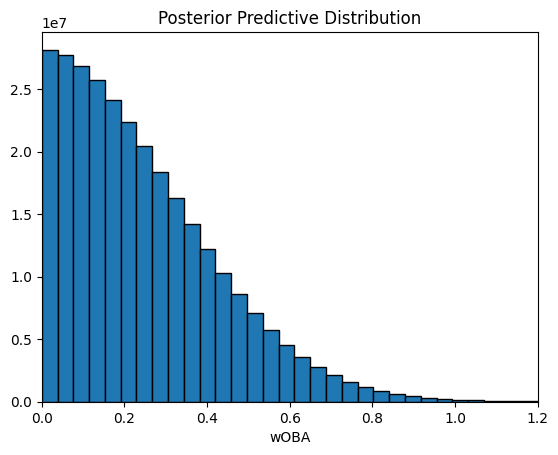

In [ ]:
# posterior predictive distribution
numpy_array = np.array(predictions_1).flatten()

plt.hist(numpy_array, bins=100, edgecolor='black')
plt.title("Posterior Predictive Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

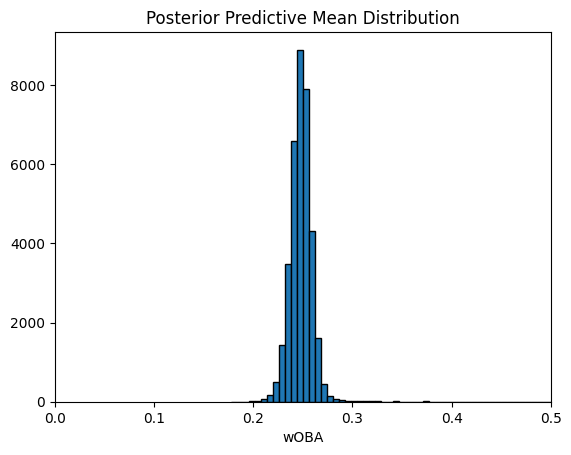

In [ ]:
# posterior predictive mean distribution
plt.hist(numpy_mean_pred, bins=100, edgecolor='black')
plt.title("Posterior Predictive Mean Distribution")
plt.xlim(0, 0.5)
plt.xlabel("wOBA")
plt.show()

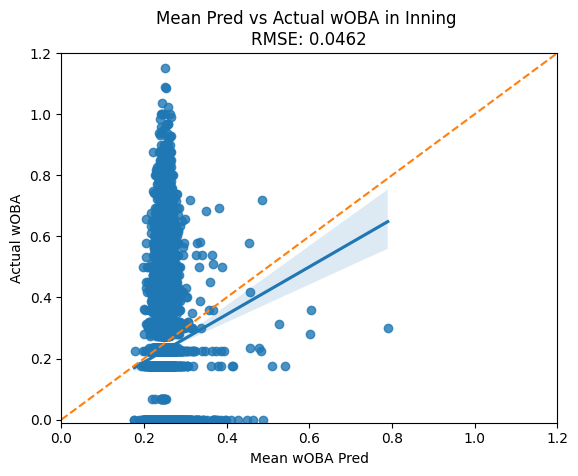

In [ ]:
# mean pred evaluation
rmse = mean_squared_error(df_innings.select(pl.col('mean_predictions')), df_innings.select(pl.col('avg_woba')))

sns.regplot(data = df_innings, x = 'mean_predictions', y = 'avg_woba')
plt.xlabel('Mean wOBA Pred')
plt.ylabel('Actual wOBA')
plt.ylim([-0.01, 1.2])
plt.xlim([0, 1.2])
plt.plot([0, 1.2], [0, 1.2], linestyle = '--')
plt.title(f'Mean Pred vs Actual wOBA in Inning \nRMSE: {round(rmse, 4)}')
plt.show()

In [ ]:
# functions for log posterior predictive density evaluation
def log_likelihood(rng_key, params, model, *args, **kwargs):
    model = handlers.condition(woba_model, params)
    model_trace = handlers.trace(model).get_trace(*args, **kwargs)
    obs_node = model_trace["obs"]
    return obs_node["fn"].log_prob(obs_node["value"])


def log_pred_density(rng_key, params, model, *args, **kwargs):
    n = list(params.values())[0].shape[0]
    log_lk_fn = vmap(
        lambda rng_key, params: log_likelihood(rng_key, params, model, *args, **kwargs)
    )
    log_lk_vals = log_lk_fn(random.split(rng_key, n), params)
    return (logsumexp(log_lk_vals, 0) - jnp.log(n)).sum()

In [ ]:
# log posterior predictive density
rng_key, rng_key_ = random.split(rng_key)
woba_jax = jnp.array(df_innings.select(pl.col('avg_woba')).to_numpy())
print(
    "Log posterior predictive density: {}".format(
        log_pred_density(
            rng_key_,
            posterior_samples,
            woba_model,
            stuff = stuff_jax,
            woba = woba_jax,
        )
    )
)

Log posterior predictive density: 15943.32421875


In [ ]:
15943.32421875/35877

0.4443884443724392

In [ ]:
# function for examining specific innings
def inning_pred_distribution(date, inning, pitcher = None, name = None):
    if name is None:
        _df = df_innings.with_columns(
            index = pl.arange(0, df_innings.height)
        ).filter((pl.col('date') == date) & (pl.col('inning') == inning) & (pl.col('pitcher') == pitcher))
    elif pitcher is None:
        _df = df_innings.with_columns(
            index = pl.arange(0, df_innings.height)
        ).filter((pl.col('date') == date) & (pl.col('inning') == inning) & (pl.col('player_name') == name))


    index = _df.select(pl.col('index')).to_numpy()[0][0]
    _preds = predictions_1[:, index, 1]

    stuff = _df.select(pl.col('avg_stuff')).to_numpy()[0][0]
    percentiles = np.percentile(_preds, [90, 75, 50, 25, 10])
    colors = ['red', 'green', 'blue', 'yellow', 'green']
    for woba, percent, color in zip(percentiles, [10, 25, 50, 75, 90], colors):
        plt.axvline(woba, color = color, linestyle = '--', alpha = 0.7, label = f'{percent}th Percentile')

    actual = _df.select(pl.col('avg_woba')).to_numpy()[0][0]
    plt.axvline(actual, color = 'black', linestyle = 'solid', alpha = 0.8, label = 'Acutal')

    plt.legend()
    plt.xlabel('Avg wOBA in Inning')
    plt.ylabel(' ')
    plt.xlim([-0.01, 1.2])

    pitcher_name = _df.select(pl.col('player_name')).to_numpy()[0][0]
    pitcher_name_split = pitcher_name.split(', ')
    pitcher_name = pitcher_name_split[1] + ' ' + pitcher_name_split[0]
    plt.title(f'{date}, {pitcher_name}, {inning}th Inning \nDistribution of Predicted wOBAs \nAvg Stuff in Inning: {round(stuff, 4)}')

    sns.histplot(_preds)
    plt.show()

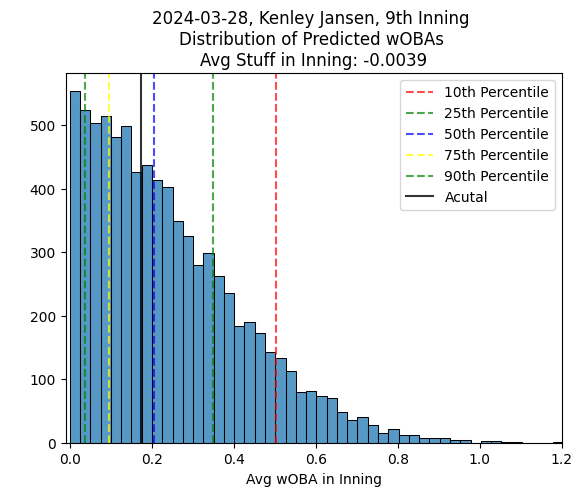

In [ ]:
inning_pred_distribution(date = '2024-03-28', inning = 9, pitcher = 445276)

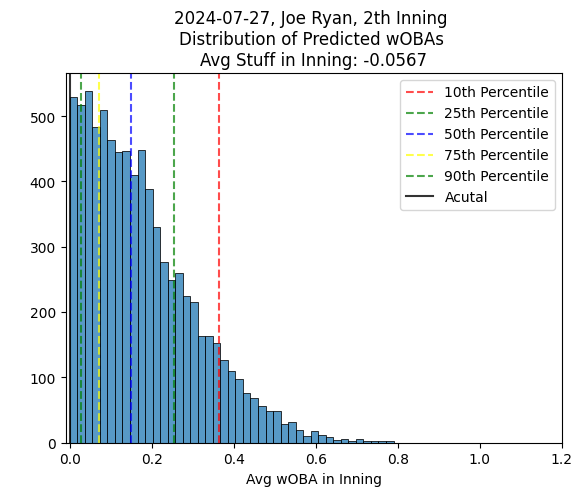

In [ ]:
inning_pred_distribution(date = '2024-07-27', inning = 2, pitcher = 657746)

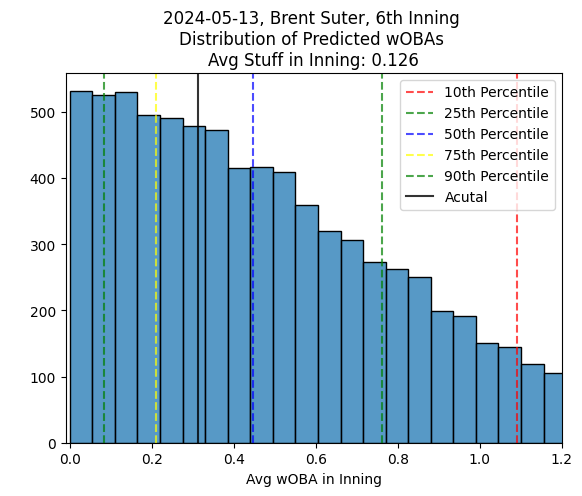

In [ ]:
inning_pred_distribution(date = '2024-05-13', inning = 6, pitcher = 608718)

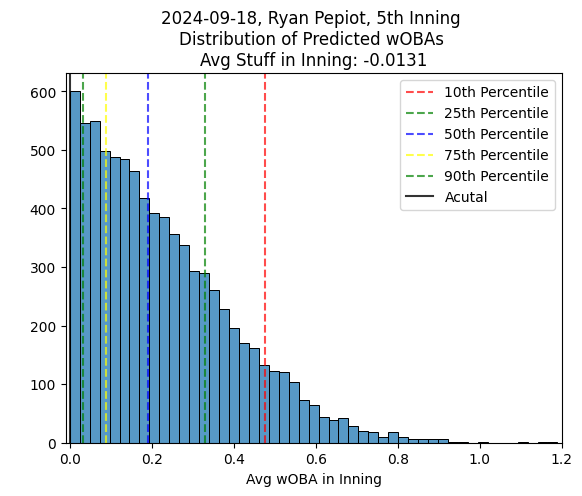

In [ ]:
inning_pred_distribution(date = '2024-09-18', inning = 5, name = 'Pepiot, Ryan')

# Hierarchical Model

In [ ]:
df_innings = pl.read_csv('/content/drive/MyDrive/Datasets/outing_predictions/df_innings.csv')
df_innings1 = df_innings.sample(n=5000, seed=42)

In [ ]:
df_innings1.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba
str,str,i64,str,i64,f64,i64,f64
"""20240427PITatSF""","""2024-04-27""",527048,"""Pérez, Martín""",2,0.011785,0,0.0
"""20240522NYMatCLE""","""2024-05-22""",683769,"""Gaddis, Hunter""",7,0.004159,0,0.3125
"""20240521SDatCIN""","""2024-05-21""",664747,"""Díaz, Alexis""",9,0.002529,0,0.233333
"""20240812NYYatCWS""","""2024-08-12""",660853,"""De Los Santos, Enyel""",8,0.011125,1,0.43
"""20240705BALatOAK""","""2024-07-05""",544150,"""Suárez, Albert""",3,-0.000886,0,0.0


In [ ]:
# hlm woba model
def woba_hlm(player_id = None, stuff = None, woba = None):
    # intercept prior on the log scale
    a = numpyro.sample('a', dist.Normal(np.log(0.2), np.log(1.25)))

    # random slope priors
    mu_bS = numpyro.sample('mu_bS', dist.Normal(25, 25))
    sigma_bS = numpyro.sample('sigma_bS', dist.HalfNormal(10))

    n_players = len(np.unique(player_id))

    # random slope
    with numpyro.plate('plate_i', size = n_players):
        bS = numpyro.sample('bS', dist.Normal(mu_bS, sigma_bS))
    S = bS[player_id] * stuff

    # model the rate for the likelihood function
    rate = numpyro.deterministic('rate', jnp.exp(a + S)) # as S increases/decreases so does runs
    rate = jnp.where(rate > 2, 2, rate) # to prevent unrealistic wobas

    # likelihood function
    numpyro.sample('obs', dist.HalfNormal(rate), obs = woba)

In [ ]:
rng_key = random.key(0)
rng_key, rng_key1 = random.split(rng_key)

In [ ]:
# simulating the prior
stuff_jax = jnp.array(df_innings1.select(pl.col('avg_stuff')).to_numpy())
pitcher_jax = jnp.array(df_innings1.select(pl.col('pitcher')).to_numpy())

prior_predictive_hlm = Predictive(woba_hlm, num_samples = 100)
prior_predictions_hlm = prior_predictive_hlm(rng_key1, stuff = stuff_jax, player_id = pitcher_jax)['obs']
mean_prior_pred_hlm = jnp.mean(prior_predictions_hlm, axis=0)

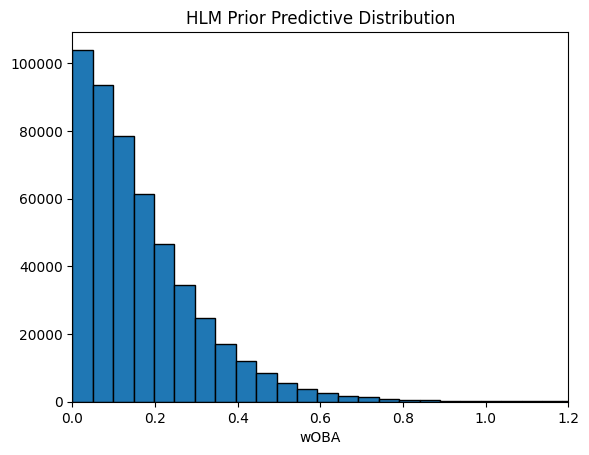

In [ ]:
# prior predictive distribution
numpy_array = np.array(prior_predictions_hlm).flatten()

plt.hist(numpy_array, bins=100, edgecolor='black')
plt.title("HLM Prior Predictive Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

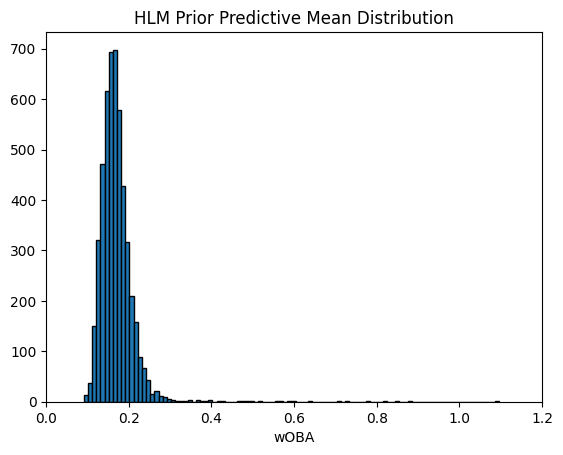

In [ ]:
# prior predictive mean distribution
numpy_array = np.array(mean_prior_pred_hlm).flatten()

plt.hist(numpy_array, bins=100, edgecolor='black')
plt.title("HLM Prior Predictive Mean Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

In [ ]:
# running inference
nuts_kernel = NUTS(woba_hlm)

woba_jax = jnp.array(df_innings1.select(pl.col('avg_woba')).to_numpy())

hlm_mcmc = MCMC(nuts_kernel, num_warmup = 1000, num_samples = 2000, num_chains = 1)
hlm_mcmc.run(
    rng_key1, stuff = stuff_jax, player_id = pitcher_jax, woba = woba_jax
)
hlm_mcmc.print_summary()

with open('/content/drive/MyDrive/Datasets/outing_predictions/hlm_mcmc.pkl', 'wb') as file:
    pickle.dump(hlm_mcmc, file)

sample: 100%|██████████| 3000/3000 [2:33:11<00:00,  3.06s/it, 1023 steps of size 1.56e-03. acc. prob=0.83]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -1.16      0.01     -1.16     -1.18     -1.15    290.02      1.00
     bS[0]      2.55     10.81      2.89    -16.01     18.69     43.99      1.00
     bS[1]      4.61      8.84      4.64     -9.72     19.66     72.48      1.01
     bS[2]      4.41      8.77      4.25    -11.35     16.61     39.86      1.05
     bS[3]      4.40     10.20      3.74    -12.19     20.00     74.31      1.04
     bS[4]      3.19     12.53      3.59    -20.05     20.87     36.47      1.01
     bS[5]      1.85     11.45      2.88    -18.72     18.90     39.88      1.01
     bS[6]      3.95     10.16      3.62    -10.79     22.69     50.75      1.02
     bS[7]      1.60     10.85      1.53    -16.75     19.89     57.44      1.00
     bS[8]      0.94     10.90      1.53    -18.84     16.98     38.86      1.03
     bS[9]      4.29     13.08      3.59    -18.86     25.77     38.24      1.02
    bS[10]      1.56     10

In [ ]:
with open('/content/drive/MyDrive/Datasets/outing_predictions/hlm_mcmc.pkl', 'rb') as f:
    hlm_mcmc = pickle.load(f)

In [ ]:
posterior_samples_hlm = hlm_mcmc.get_samples()

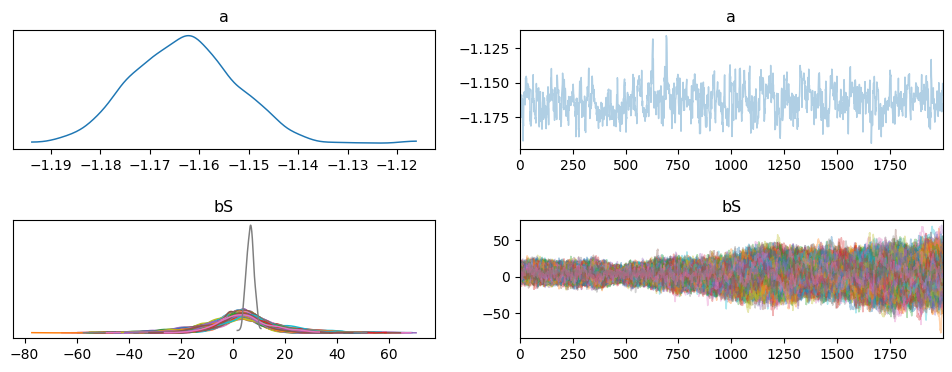

In [ ]:
# trace plots
data = az.from_numpyro(hlm_mcmc)

az.plot_trace(data, var_names = ['a', 'bS'], compact = True)
plt.subplots_adjust(hspace = 0.6)
plt.show()

In [ ]:
# prediction functions
def predict_hlm(rng_key, post_samples, model, *args, **kwargs):
    model = handlers.seed(handlers.condition(woba_hlm, post_samples), rng_key)
    model_trace = handlers.trace(model).get_trace(*args, **kwargs)
    return model_trace["obs"]["value"]

predict_fn_hlm = vmap(
    lambda rng_key, samples: predict_hlm(
        rng_key, samples, woba_hlm, stuff = stuff_jax, player_id = pitcher_jax
    )
)

In [ ]:
# make posterior preds
rng_key, rng_key1 = random.split(rng_key)

predictions_hlm = predict_fn_hlm(random.split(rng_key1, 2000), posterior_samples_hlm)

mean_pred = jnp.mean(predictions_hlm, axis=0)
numpy_mean_pred = np.array(mean_pred).flatten()

df_innings1 = df_innings1.with_columns(
    mean_predictions = numpy_mean_pred
)

In [ ]:
df_innings1.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240427PITatSF""","""2024-04-27""",527048,"""Pérez, Martín""",2,0.011785,0,0.0,0.263211
"""20240522NYMatCLE""","""2024-05-22""",683769,"""Gaddis, Hunter""",7,0.004159,0,0.3125,0.257803
"""20240521SDatCIN""","""2024-05-21""",664747,"""Díaz, Alexis""",9,0.002529,0,0.233333,0.249996
"""20240812NYYatCWS""","""2024-08-12""",660853,"""De Los Santos, Enyel""",8,0.011125,1,0.43,0.261443
"""20240705BALatOAK""","""2024-07-05""",544150,"""Suárez, Albert""",3,-0.000886,0,0.0,0.241237


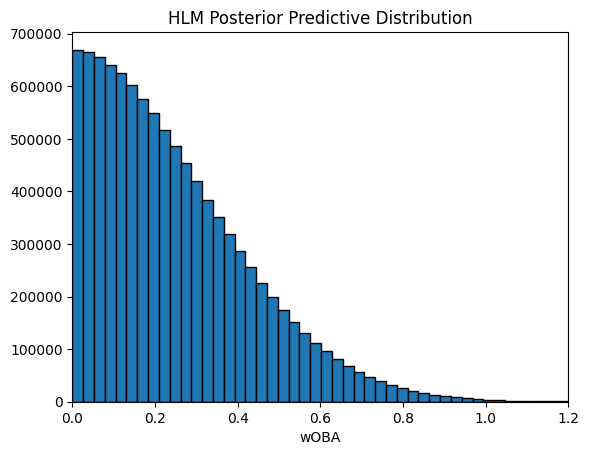

In [ ]:
# hlm posterior predictive distribution
plt.hist(predictions_hlm.flatten(), bins=100, edgecolor='black')
plt.title("HLM Posterior Predictive Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

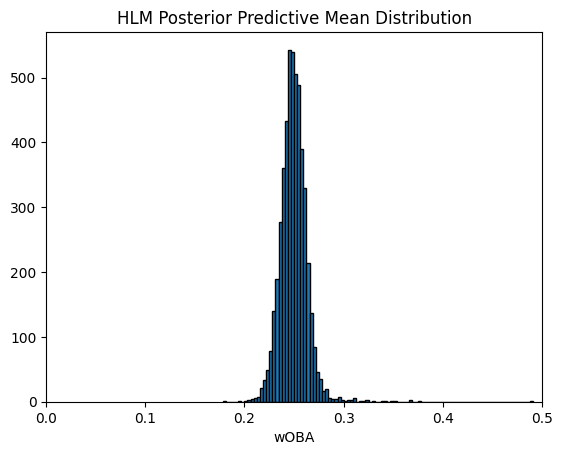

In [ ]:
# posterior predictive mean distribution
plt.hist(numpy_mean_pred, bins=100, edgecolor='black')
plt.title("HLM Posterior Predictive Mean Distribution")
plt.xlim(0, 0.5)
plt.xlabel("wOBA")
plt.show()

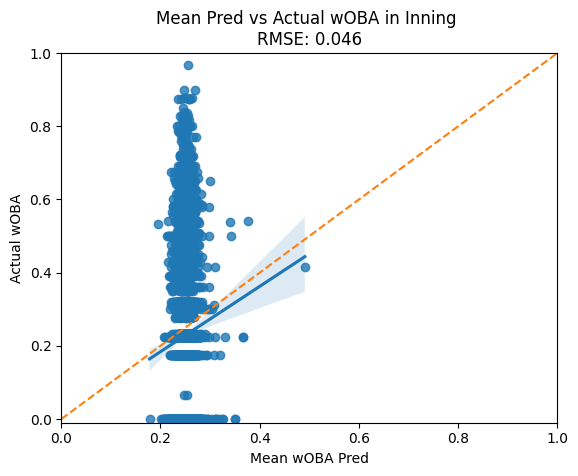

In [ ]:
# mean pred evaluation
rmse = mean_squared_error(df_innings1.select(pl.col('mean_predictions')), df_innings1.select(pl.col('avg_woba')))

sns.regplot(data = df_innings1, x = 'mean_predictions', y = 'avg_woba')
plt.xlabel('Mean wOBA Pred')
plt.ylabel('Actual wOBA')
plt.ylim([-0.01, 1])
plt.xlim([0, 1])
plt.plot([0, 1], [0, 1], linestyle = '--')
plt.title(f'Mean Pred vs Actual wOBA in Inning \nRMSE: {round(rmse, 4)}')
plt.show()

In [ ]:
# functions for log posterior predictive density evaluation
def log_likelihood_hlm(rng_key, params, model, *args, **kwargs):
    model = handlers.condition(woba_hlm, params)
    model_trace = handlers.trace(model).get_trace(*args, **kwargs)
    obs_node = model_trace["obs"]
    return obs_node["fn"].log_prob(obs_node["value"])


def log_pred_density(rng_key, params, model, *args, **kwargs):
    n = list(params.values())[0].shape[0]
    log_lk_fn = vmap(
        lambda rng_key, params: log_likelihood_hlm(rng_key, params, model, *args, **kwargs)
    )
    log_lk_vals = log_lk_fn(random.split(rng_key, n), params)
    return (logsumexp(log_lk_vals, 0) - jnp.log(n)).sum()

In [ ]:
# log posterior predictive density
rng_key, rng_key_ = random.split(rng_key)
woba_jax = jnp.array(df_innings1.select(pl.col('avg_woba')).to_numpy())
print(
    "Log posterior predictive density: {}".format(
        log_pred_density(
            rng_key = rng_key_,
            params = posterior_samples_hlm,
            model = woba_hlm,
            stuff = stuff_jax,
            player_id = pitcher_jax,
            woba = woba_jax
        )
    )
)

Log posterior predictive density: 2196.14599609375


In [ ]:
2196.14599609375/5000

0.43922919921875

In [ ]:
# function for examining specific innings
def inning_pred_distribution_hlm(date, inning, pitcher = None, name = None):
    if name is None:
        _df = df_innings1.with_columns(
            index = pl.arange(0, df_innings1.height)
        ).filter((pl.col('date') == date) & (pl.col('inning') == inning) & (pl.col('pitcher') == pitcher))
    elif pitcher is None:
        _df = df_innings1.with_columns(
            index = pl.arange(0, df_innings1.height)
        ).filter((pl.col('date') == date) & (pl.col('inning') == inning) & (pl.col('player_name') == name))


    index = _df.select(pl.col('index')).to_numpy()[0][0]
    _preds = predictions_hlm[:, index, 1]

    stuff = _df.select(pl.col('avg_stuff')).to_numpy()[0][0]
    percentiles = np.percentile(_preds, [90, 75, 50, 25, 10])
    colors = ['red', 'green', 'blue', 'yellow', 'green']
    for woba, percent, color in zip(percentiles, [10, 25, 50, 75, 90], colors):
        plt.axvline(woba, color = color, linestyle = '--', alpha = 0.7, label = f'{percent}th Percentile')

    actual = _df.select(pl.col('avg_woba')).to_numpy()[0][0]
    plt.axvline(actual, color = 'black', linestyle = 'solid', alpha = 0.8, label = 'Acutal')

    plt.legend()
    plt.xlabel('Avg wOBA in Inning')
    plt.ylabel(' ')
    plt.xlim([-0.01, 1.2])

    pitcher_name = _df.select(pl.col('player_name')).to_numpy()[0][0]
    pitcher_name_split = pitcher_name.split(', ')
    pitcher_name = pitcher_name_split[1] + ' ' + pitcher_name_split[0]
    plt.title(f'{date}, {pitcher_name}, {inning}th Inning \nDistribution of Predicted wOBAs \nAvg Stuff in Inning: {round(stuff, 4)}')

    sns.histplot(_preds)
    plt.show()

In [ ]:
df_innings1.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240427PITatSF""","""2024-04-27""",527048,"""Pérez, Martín""",2,0.011785,0,0.0,0.263211
"""20240522NYMatCLE""","""2024-05-22""",683769,"""Gaddis, Hunter""",7,0.004159,0,0.3125,0.257803
"""20240521SDatCIN""","""2024-05-21""",664747,"""Díaz, Alexis""",9,0.002529,0,0.233333,0.249996
"""20240812NYYatCWS""","""2024-08-12""",660853,"""De Los Santos, Enyel""",8,0.011125,1,0.43,0.261443
"""20240705BALatOAK""","""2024-07-05""",544150,"""Suárez, Albert""",3,-0.000886,0,0.0,0.241237


In [ ]:
df_innings1.sort(by='avg_stuff').head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240927LADatCOL""","""2024-09-27""",664875,"""Lawrence, Justin""",9,-0.053691,0,0.0,0.177934
"""20240819BOSatHOU""","""2024-08-19""",608371,"""Sims, Lucas""",8,-0.032247,1,0.533333,0.194476
"""20240501CLEatHOU""","""2024-05-01""",661403,"""Clase, Emmanuel""",10,-0.030176,0,0.0,0.204641
"""20240521MINatWSH""","""2024-05-21""",643377,"""Jax, Griffin""",8,-0.029271,0,0.0,0.208313
"""20240910OAKatHOU""","""2024-09-10""",650556,"""Abreu, Bryan""",11,-0.028395,0,0.0,0.201284


In [ ]:
df_innings1.sort(by='avg_stuff', descending = True).head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240511CINatSF""","""2024-05-11""",608718,"""Suter, Brent""",7,0.101363,1,0.416667,0.491018
"""20240825LAAatTOR""","""2024-08-25""",519326,"""Strickland, Hunter""",6,0.062937,2,0.54,0.377294
"""20240610TORatMIL""","""2024-06-10""",663893,"""Little, Brendon""",7,0.056118,0,0.225,0.367309
"""20240909NYMatTOR""","""2024-09-09""",642232,"""Yarbrough, Ryan""",6,0.053949,0,0.0,0.350936
"""20240505SFatPHI""","""2024-05-05""",663546,"""Hjelle, Sean""",6,0.052507,0,0.225,0.366368


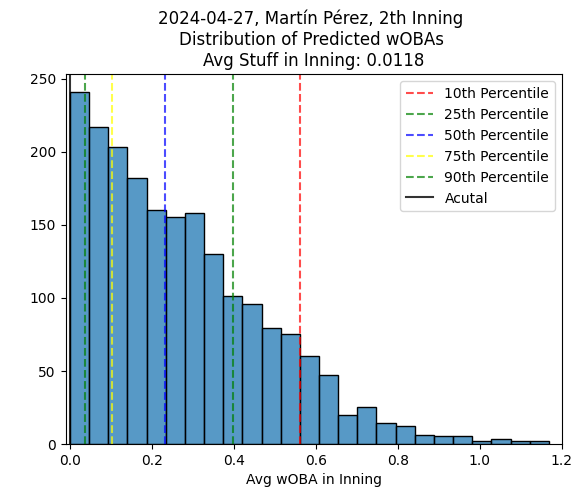

In [ ]:
inning_pred_distribution_hlm(date="2024-04-27", inning = 2, pitcher = 527048)

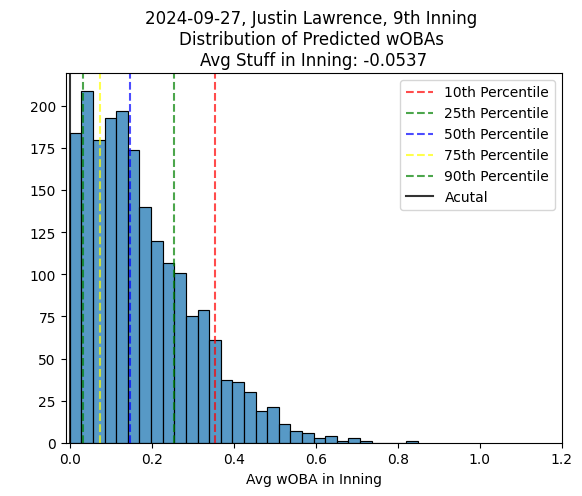

In [ ]:
inning_pred_distribution_hlm(date="2024-09-27", inning = 9, pitcher = 664875)

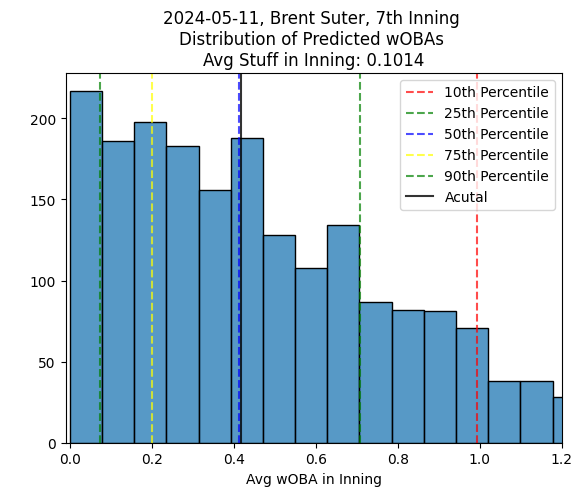

In [ ]:
inning_pred_distribution_hlm(date="2024-05-11", inning = 7, pitcher = 608718)

# Exponential Distribution

In [ ]:
df_innings = pl.read_csv('/content/drive/MyDrive/Datasets/outing_predictions/df_innings.csv')

In [ ]:
# exponential model
def exponential_model(stuff = None, woba = None):
    # intercept prior on the log scale
    a = numpyro.sample('a', dist.Normal(np.log(12), np.log(1.1)))

    S = 0.0
    if stuff is not None:
        # stuff prior
        bS = numpyro.sample('bS', dist.Normal(25, 25))
        S = bS * stuff

    # model the rate for the likelihood function
    rate = numpyro.deterministic('rate', jnp.exp(a - S)) # as S increases/decreases so does runs
    rate = jnp.where(rate < 1, 1, rate) # to prevent unrealistic wobas

    # likelihood function
    numpyro.sample('obs', dist.Exponential(rate), obs = woba)

In [ ]:
rng_key = random.key(0)
rng_key, rng_key1 = random.split(rng_key)

In [ ]:
# simulating the prior
prior_predictive = Predictive(exponential_model, num_samples = 100)
stuff_jax = jnp.array(df_innings.select(pl.col('avg_stuff')).to_numpy())
prior_predictions_exp = prior_predictive(rng_key1, stuff = stuff_jax)['obs']
mean_prior_pred_exp = jnp.mean(prior_predictions_exp, axis=0)

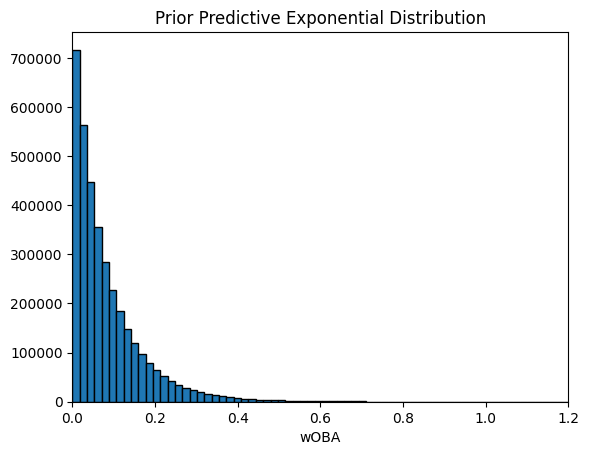

In [ ]:
# prior predictive distribution
numpy_array = np.array(prior_predictions_exp).flatten()

plt.hist(numpy_array, bins=500, edgecolor='black')
plt.title("Prior Predictive Exponential Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

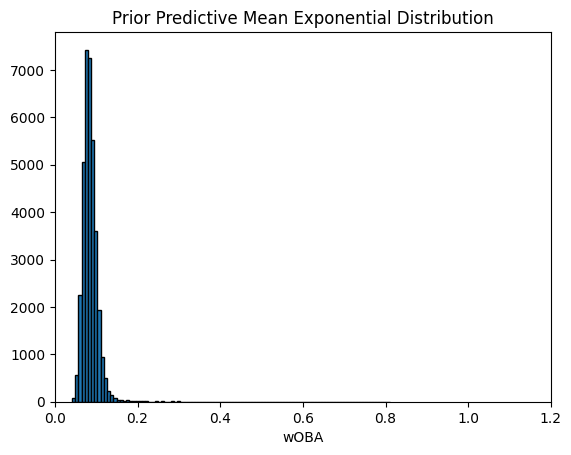

In [ ]:
# prior predictive mean distribution
numpy_array = np.array(mean_prior_pred_exp)

plt.hist(numpy_array, bins=100, edgecolor='black')
plt.title("Prior Predictive Mean Exponential Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

In [ ]:
# running inference
kernel = NUTS(exponential_model)

rng_keys = random.split(rng_key, 4)
woba_jax = jnp.array(df_innings.select(pl.col('avg_woba')).to_numpy())

exp_mcmc = MCMC(kernel, num_warmup = 1000, num_samples = 2000, num_chains = 4)
exp_mcmc.run(
    rng_keys, stuff = stuff_jax, woba = woba_jax
)
exp_mcmc.print_summary()

<ipython-input-8-b71b046430f5>:7: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  exp_mcmc = MCMC(kernel, num_warmup = 1000, num_samples = 2000, num_chains = 4)
sample: 100%|██████████| 3000/3000 [00:19<00:00, 150.04it/s, 3 steps of size 8.88e-01. acc. prob=0.90]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a      1.49      0.01      1.49      1.48      1.50   7478.31      1.00
        bS      8.13      0.77      8.14      6.93      9.45   5528.06      1.00

Number of divergences: 0


In [ ]:
with open('/content/drive/MyDrive/Datasets/outing_predictions/exp_mcmc.pkl', 'wb') as file:
    pickle.dump(exp_mcmc, file)

In [ ]:
with open('/content/drive/MyDrive/Datasets/outing_predictions/exp_mcmc.pkl', 'rb') as f:
    exp_mcmc = pickle.load(f)

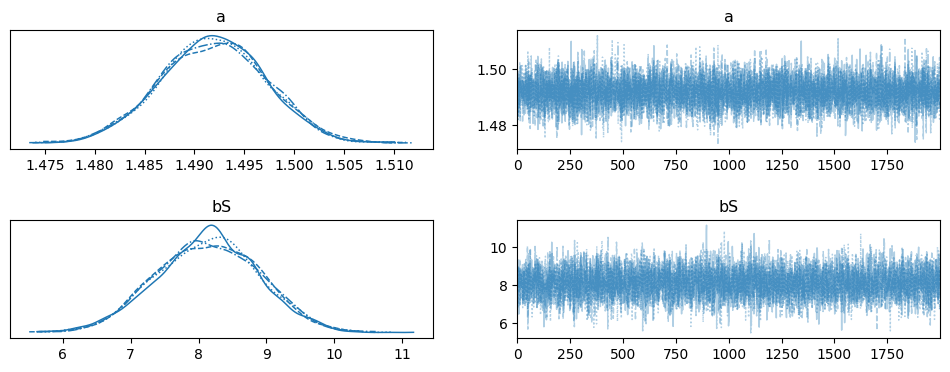

In [ ]:
# trace plots
data = az.from_numpyro(exp_mcmc)

az.plot_trace(data, var_names = ['a', 'bS'], compact = True)
plt.subplots_adjust(hspace = 0.6)
plt.show()

In [ ]:
from numpyro import handlers
from jax import vmap

# prediction functions
def predict_exp(rng_key, post_samples, model, *args, **kwargs):
    model = handlers.seed(handlers.condition(exponential_model, post_samples), rng_key)
    model_trace = handlers.trace(model).get_trace(*args, **kwargs)
    return model_trace["obs"]["value"]

predict_fn_exp = vmap(
    lambda rng_key, samples: predict_exp(
        rng_key, samples, exponential_model, stuff = stuff_jax
    )
)

In [ ]:
# make posterior preds
rng_key, rng_key1 = random.split(rng_key)

exp_posterior_samples = exp_mcmc.get_samples()
predictions_exp = predict_fn_exp(random.split(rng_key1, 8000), exp_posterior_samples)

mean_pred_exp = jnp.mean(predictions_exp, axis=0)
numpy_mean_pred_exp = np.array(mean_pred_exp).flatten()
df_innings = df_innings.with_columns(
    mean_predictions = numpy_mean_pred_exp
)

In [ ]:
df_innings.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240328BOSatSEA""","""2024-03-28""",445276,"""Jansen, Kenley""",9,-0.003892,0,0.175,0.214052
"""20240328BOSatSEA""","""2024-03-28""",455119,"""Martin, Chris""",8,-0.008354,0,0.3125,0.208177
"""20240328CHCatTEX""","""2024-03-28""",489446,"""Yates, Kirby""",8,-0.002635,0,0.0,0.219795
"""20240328CHCatTEX""","""2024-03-28""",502085,"""Robertson, David""",10,-0.010282,0,0.175,0.207498
"""20240328SFatSD""","""2024-03-28""",506433,"""Darvish, Yu""",1,-0.005162,0,0.0,0.214497


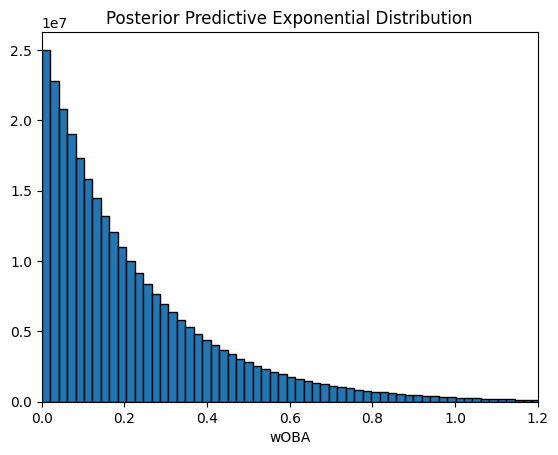

In [ ]:
# posterior predictive distribution
numpy_array = np.array(predictions_exp).flatten()

plt.hist(numpy_array, bins=500, edgecolor='black')
plt.title("Posterior Predictive Exponential Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

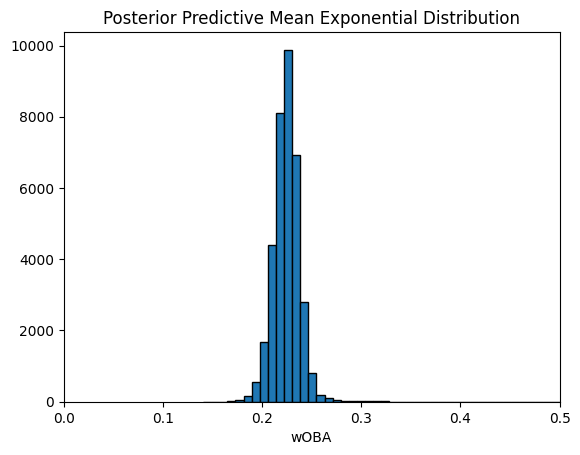

In [ ]:
# posterior predictive mean distribution
plt.hist(numpy_mean_pred_exp, bins=100, edgecolor='black')
plt.title("Posterior Predictive Mean Exponential Distribution")
plt.xlim(0, 0.5)
plt.xlabel("wOBA")
plt.show()

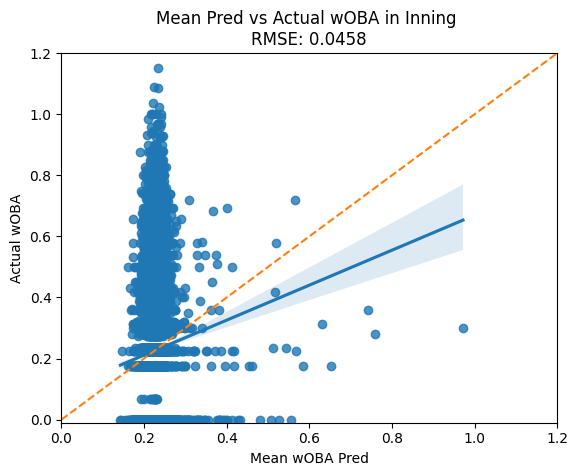

In [ ]:
# mean pred evaluation
rmse = mean_squared_error(df_innings.select(pl.col('mean_predictions')), df_innings.select(pl.col('avg_woba')))

sns.regplot(data = df_innings, x = 'mean_predictions', y = 'avg_woba')
plt.xlabel('Mean wOBA Pred')
plt.ylabel('Actual wOBA')
plt.ylim([-0.01, 1.2])
plt.xlim([0, 1.2])
plt.plot([0, 1.2], [0, 1.2], linestyle = '--')
plt.title(f'Mean Pred vs Actual wOBA in Inning \nRMSE: {round(rmse, 4)}')
plt.show()

In [ ]:
from jax.scipy.special import logsumexp

# functions for log posterior predictive density evaluation
def log_likelihood(rng_key, params, model, *args, **kwargs):
    model = handlers.condition(exponential_model, params)
    model_trace = handlers.trace(model).get_trace(*args, **kwargs)
    obs_node = model_trace["obs"]
    return obs_node["fn"].log_prob(obs_node["value"])


def log_pred_density(rng_key, params, model, *args, **kwargs):
    n = list(params.values())[0].shape[0]
    log_lk_fn = vmap(
        lambda rng_key, params: log_likelihood(rng_key, params, model, *args, **kwargs)
    )
    log_lk_vals = log_lk_fn(random.split(rng_key, n), params)
    return (logsumexp(log_lk_vals, 0) - jnp.log(n)).sum()

In [ ]:
# log posterior predictive density
rng_key, rng_key_ = random.split(rng_key)
woba_jax = jnp.array(df_innings.select(pl.col('avg_woba')).to_numpy())
print(
    "Log posterior predictive density: {}".format(
        log_pred_density(
            rng_key_,
            exp_posterior_samples,
            exponential_model,
            stuff = stuff_jax,
            woba = woba_jax,
        )/35877
    )
)

Log posterior predictive density: 17632.86328125


In [ ]:
17632.86328125/35877

0.4914809845095744

In [ ]:
# function for examining specific innings
def inning_pred_exp_distribution(date, inning, pitcher = None, name = None):
    if name is None:
        _df = df_innings.with_columns(
            index = pl.arange(0, df_innings.height)
        ).filter((pl.col('date') == date) & (pl.col('inning') == inning) & (pl.col('pitcher') == pitcher))
    elif pitcher is None:
        _df = df_innings.with_columns(
            index = pl.arange(0, df_innings.height)
        ).filter((pl.col('date') == date) & (pl.col('inning') == inning) & (pl.col('player_name') == name))


    index = _df.select(pl.col('index')).to_numpy()[0][0]
    _preds = predictions_exp[:, index, 1]

    stuff = _df.select(pl.col('avg_stuff')).to_numpy()[0][0]
    percentiles = np.percentile(_preds, [90, 75, 50, 25, 10])
    colors = ['red', 'green', 'blue', 'yellow', 'green']
    for woba, percent, color in zip(percentiles, [10, 25, 50, 75, 90], colors):
        plt.axvline(woba, color = color, linestyle = '--', alpha = 0.7, label = f'{percent}th Percentile')

    actual = _df.select(pl.col('avg_woba')).to_numpy()[0][0]
    plt.axvline(actual, color = 'black', linestyle = 'solid', alpha = 0.8, label = 'Acutal')

    plt.legend()
    plt.xlabel('Avg wOBA in Inning')
    plt.ylabel(' ')
    plt.xlim([-0.01, 1.2])

    pitcher_name = _df.select(pl.col('player_name')).to_numpy()[0][0]
    pitcher_name_split = pitcher_name.split(', ')
    pitcher_name = pitcher_name_split[1] + ' ' + pitcher_name_split[0]
    plt.title(f'{date}, {pitcher_name}, {inning}th Inning \nDistribution of Predicted wOBAs \nAvg Stuff in Inning: {round(stuff, 4)}')

    sns.histplot(_preds)
    plt.show()

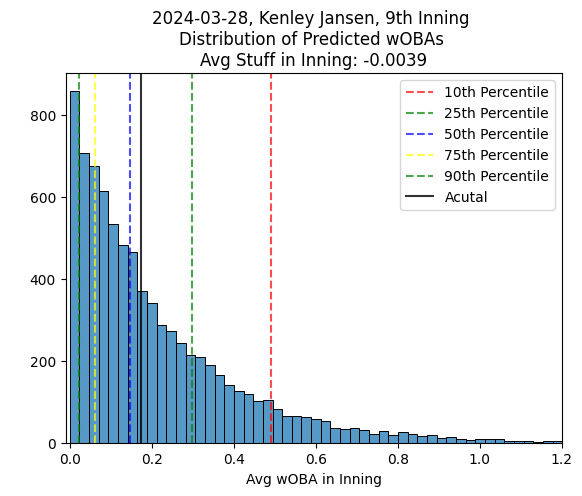

In [ ]:
inning_pred_exp_distribution(date = '2024-03-28', inning = 9, pitcher = 445276)

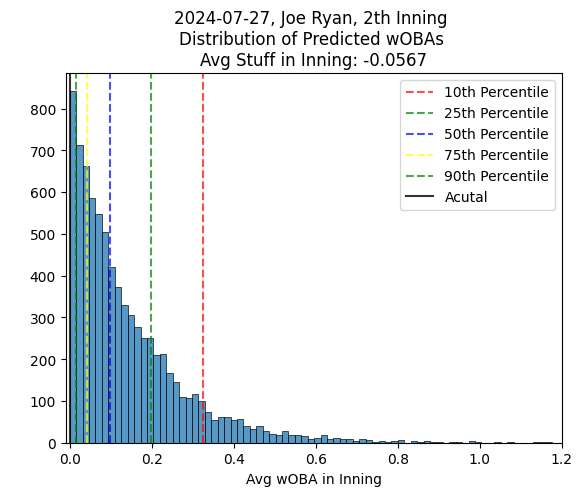

In [ ]:
inning_pred_exp_distribution(date = '2024-07-27', inning = 2, pitcher = 657746)

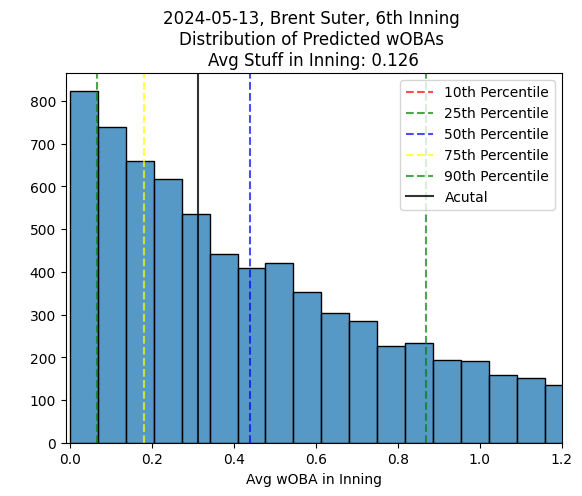

In [ ]:
inning_pred_exp_distribution(date = '2024-05-13', inning = 6, pitcher = 608718)

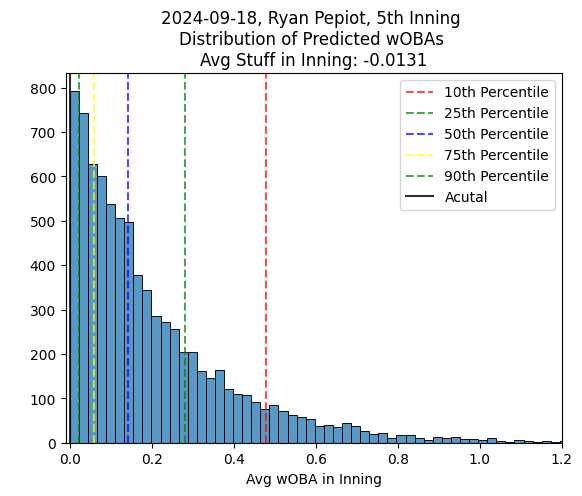

In [ ]:
inning_pred_exp_distribution(date = '2024-09-18', inning = 5, name = 'Pepiot, Ryan')

# Hierarchical Exponential

In [ ]:
df_innings = pl.read_csv('/content/drive/MyDrive/Datasets/outing_predictions/df_innings.csv')
df_innings1 = df_innings.sample(n=5000, seed=42)

In [ ]:
df_innings1.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba
str,str,i64,str,i64,f64,i64,f64
"""20240427PITatSF""","""2024-04-27""",527048,"""Pérez, Martín""",2,0.011785,0,0.0
"""20240522NYMatCLE""","""2024-05-22""",683769,"""Gaddis, Hunter""",7,0.004159,0,0.3125
"""20240521SDatCIN""","""2024-05-21""",664747,"""Díaz, Alexis""",9,0.002529,0,0.233333
"""20240812NYYatCWS""","""2024-08-12""",660853,"""De Los Santos, Enyel""",8,0.011125,1,0.43
"""20240705BALatOAK""","""2024-07-05""",544150,"""Suárez, Albert""",3,-0.000886,0,0.0


In [ ]:
# hlm exponential woba model
def woba_exp_hlm(player_id = None, stuff = None, woba = None):
    # intercept prior on the log scale
    a = numpyro.sample('a', dist.Normal(np.log(12), np.log(1.1)))

    # random slope priors
    mu_bS = numpyro.sample('mu_bS', dist.Normal(0, 25))
    sigma_bS = numpyro.sample('sigma_bS', dist.HalfNormal(10))

    n_players = len(np.unique(player_id))

    # random slope
    with numpyro.plate('plate_i', size = n_players):
        bS = numpyro.sample('bS', dist.Normal(mu_bS, sigma_bS))
    S = bS[player_id] * stuff

    # model the rate for the likelihood function
    rate = numpyro.deterministic('rate', jnp.exp(a + S)) # as S increases/decreases so does runs
    rate = jnp.where(rate < 1, 1, rate) # to prevent unrealistic wobas

    # likelihood function
    numpyro.sample('obs', dist.Exponential(rate), obs = woba)

In [ ]:
rng_key = random.key(0)
rng_key, rng_key1 = random.split(rng_key)

In [ ]:
# simulating the prior
stuff_jax = jnp.array(df_innings1.select(pl.col('avg_stuff')).to_numpy())
pitcher_jax = jnp.array(df_innings1.select(pl.col('pitcher')).to_numpy())

prior_predictive_exp_hlm = Predictive(woba_exp_hlm, num_samples = 100)
prior_predictions_exp_hlm = prior_predictive_exp_hlm(rng_key1, stuff = stuff_jax, player_id = pitcher_jax)['obs']
mean_prior_pred_exp_hlm = jnp.mean(prior_predictions_exp_hlm, axis=0)

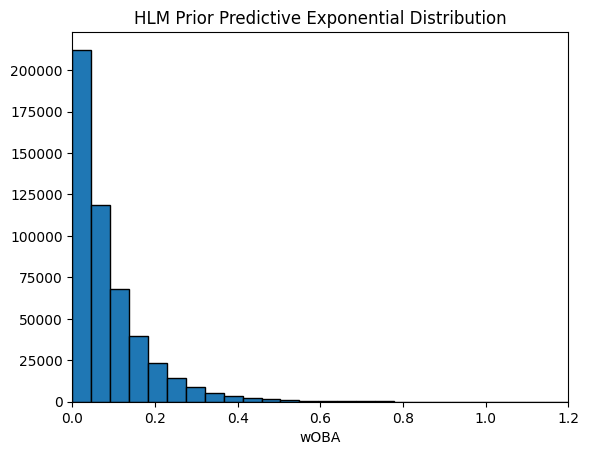

In [ ]:
# prior predictive distribution
numpy_array = np.array(prior_predictions_exp_hlm).flatten()

plt.hist(numpy_array, bins=100, edgecolor='black')
plt.title("HLM Prior Predictive Exponential Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

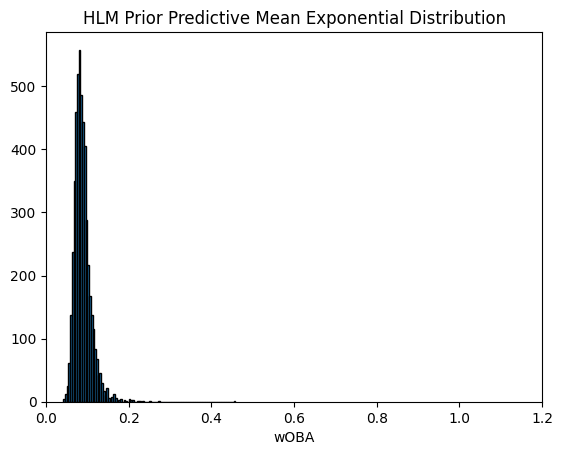

In [ ]:
# prior predictive mean distribution
numpy_array = np.array(mean_prior_pred_exp_hlm).flatten()

plt.hist(numpy_array, bins=100, edgecolor='black')
plt.title("HLM Prior Predictive Mean Exponential Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

In [ ]:
# running inference
nuts_kernel = NUTS(woba_exp_hlm)

woba_jax = jnp.array(df_innings1.select(pl.col('avg_woba')).to_numpy())

hlm_exp_mcmc = MCMC(nuts_kernel, num_warmup = 1000, num_samples = 2000, num_chains = 1)
hlm_exp_mcmc.run(
    rng_key1, stuff = stuff_jax, player_id = pitcher_jax, woba = woba_jax
)
hlm_exp_mcmc.print_summary()

with open('/content/drive/MyDrive/Datasets/outing_predictions/hlm_exp_mcmc.pkl', 'wb') as file:
    pickle.dump(hlm_exp_mcmc, file)

sample: 100%|██████████| 3000/3000 [2:38:21<00:00,  3.17s/it, 1023 steps of size 1.01e-03. acc. prob=0.87]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a      1.50      0.01      1.50      1.47      1.52    114.03      1.04
     bS[0]     -0.91      3.72     -1.30     -6.75      5.08     55.42      1.03
     bS[1]     -0.96      3.14     -0.99     -6.25      3.98     54.59      1.00
     bS[2]     -0.73      2.81     -0.70     -5.25      3.99     28.30      1.09
     bS[3]     -1.07      3.78     -1.14     -6.90      4.86     69.18      1.05
     bS[4]     -1.58      4.43     -1.65     -9.31      5.64     49.19      1.00
     bS[5]     -1.56      4.01     -1.16     -8.15      4.40     38.35      1.01
     bS[6]     -1.44      4.25     -1.82     -8.81      6.06     12.84      1.01
     bS[7]     -1.62      3.41     -1.70     -7.63      3.25     68.79      1.00
     bS[8]     -2.01      3.51     -2.47     -7.67      4.01     37.21      1.00
     bS[9]     -0.76      4.45     -1.01     -8.06      6.85     40.73      1.01
    bS[10]     -1.72      3

In [ ]:
with open('/content/drive/MyDrive/Datasets/outing_predictions/hlm_exp_mcmc.pkl', 'rb') as f:
    hlm_exp_mcmc = pickle.load(f)

In [ ]:
hlm_exp_posterior_samples = hlm_exp_mcmc.get_samples()

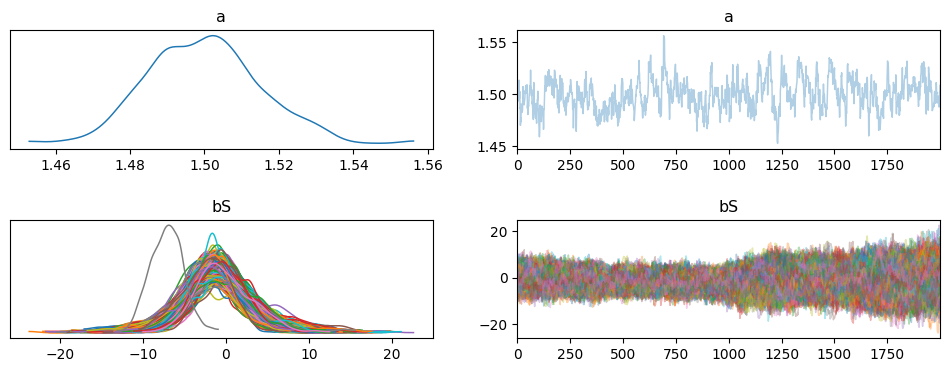

In [ ]:
# trace plots
data = az.from_numpyro(hlm_exp_mcmc)

az.plot_trace(data, var_names = ['a', 'bS'], compact = True)
plt.subplots_adjust(hspace = 0.6)
plt.show()

In [ ]:
# prediction functions
def predict_exp_hlm(rng_key, post_samples, model, *args, **kwargs):
    model = handlers.seed(handlers.condition(woba_exp_hlm, post_samples), rng_key)
    model_trace = handlers.trace(model).get_trace(*args, **kwargs)
    return model_trace["obs"]["value"]

predict_fn_exp_hlm = vmap(
    lambda rng_key, samples: predict_exp_hlm(
        rng_key, samples, woba_exp_hlm, stuff = stuff_jax, player_id = pitcher_jax
    )
)

In [ ]:
# make posterior preds
rng_key, rng_key1 = random.split(rng_key)

predictions_exp_hlm = predict_fn_exp_hlm(random.split(rng_key1, 2000), hlm_exp_posterior_samples)

mean_pred_exp_hlm = jnp.mean(predictions_exp_hlm, axis=0)
numpy_mean_pred_exp_hlm = np.array(mean_pred_exp_hlm).flatten()
df_innings1 = df_innings1.with_columns(
    mean_predictions = numpy_mean_pred_exp_hlm
)

In [ ]:
df_innings1.head()

game_id,date,pitcher,player_name,inning,avg_stuff,runs,avg_woba,mean_predictions
str,str,i64,str,i64,f64,i64,f64,f32
"""20240427PITatSF""","""2024-04-27""",527048,"""Pérez, Martín""",2,0.011785,0,0.0,0.245519
"""20240522NYMatCLE""","""2024-05-22""",683769,"""Gaddis, Hunter""",7,0.004159,0,0.3125,0.227172
"""20240521SDatCIN""","""2024-05-21""",664747,"""Díaz, Alexis""",9,0.002529,0,0.233333,0.224209
"""20240812NYYatCWS""","""2024-08-12""",660853,"""De Los Santos, Enyel""",8,0.011125,1,0.43,0.241327
"""20240705BALatOAK""","""2024-07-05""",544150,"""Suárez, Albert""",3,-0.000886,0,0.0,0.222523


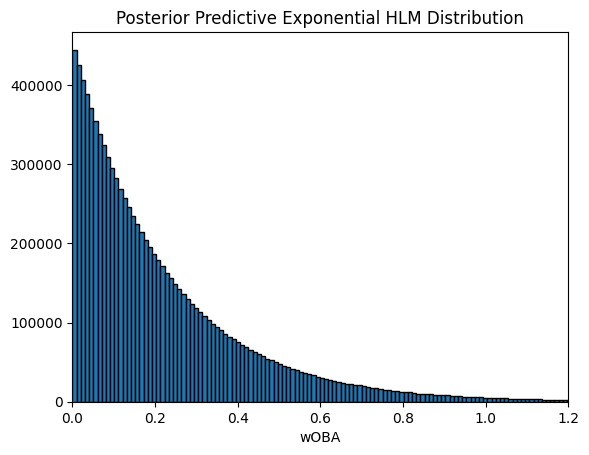

In [ ]:
# posterior predictive distribution
numpy_array = np.array(predictions_exp_hlm).flatten()

plt.hist(numpy_array, bins=500, edgecolor='black')
plt.title("Posterior Predictive Exponential HLM Distribution")
plt.xlim(0, 1.2)
plt.xlabel("wOBA")
plt.show()

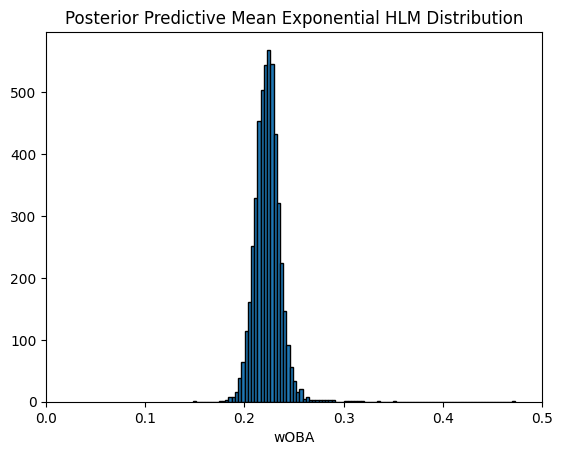

In [ ]:
# posterior predictive mean distribution
plt.hist(numpy_mean_pred_exp_hlm, bins=100, edgecolor='black')
plt.title("Posterior Predictive Mean Exponential HLM Distribution")
plt.xlim(0, 0.5)
plt.xlabel("wOBA")
plt.show()

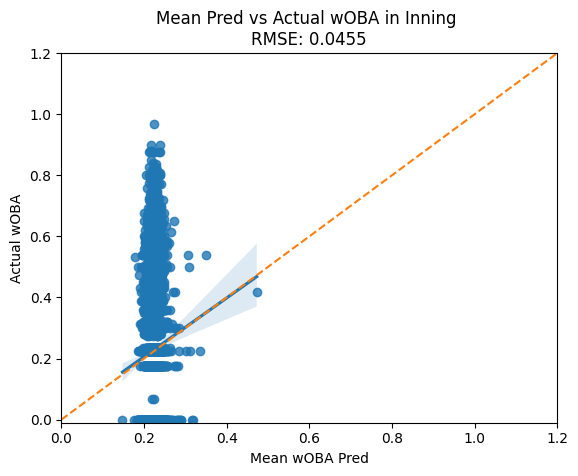

In [ ]:
# mean pred evaluation
rmse = mean_squared_error(df_innings1.select(pl.col('mean_predictions')), df_innings1.select(pl.col('avg_woba')))

sns.regplot(data = df_innings1, x = 'mean_predictions', y = 'avg_woba')
plt.xlabel('Mean wOBA Pred')
plt.ylabel('Actual wOBA')
plt.ylim([-0.01, 1.2])
plt.xlim([0, 1.2])
plt.plot([0, 1.2], [0, 1.2], linestyle = '--')
plt.title(f'Mean Pred vs Actual wOBA in Inning \nRMSE: {round(rmse, 4)}')
plt.show()

In [ ]:
# functions for log posterior predictive density evaluation
def log_likelihood_exp_hlm(rng_key, params, model, *args, **kwargs):
    model = handlers.condition(woba_exp_hlm, params)
    model_trace = handlers.trace(model).get_trace(*args, **kwargs)
    obs_node = model_trace["obs"]
    return obs_node["fn"].log_prob(obs_node["value"])


def log_pred_density_exp_hlm(rng_key, params, model, *args, **kwargs):
    n = list(params.values())[0].shape[0]
    log_lk_fn = vmap(
        lambda rng_key, params: log_likelihood_exp_hlm(rng_key, params, model, *args, **kwargs)
    )
    log_lk_vals = log_lk_fn(random.split(rng_key, n), params)
    return (logsumexp(log_lk_vals, 0) - jnp.log(n)).sum()

In [ ]:
# log posterior predictive density
rng_key, rng_key_ = random.split(rng_key)
woba_jax = jnp.array(df_innings1.select(pl.col('avg_woba')).to_numpy())
print(
    "Log posterior predictive density: {}".format(
        log_pred_density_exp_hlm(
            rng_key = rng_key_,
            params = hlm_exp_posterior_samples,
            model = woba_exp_hlm,
            stuff = stuff_jax,
            player_id = pitcher_jax,
            woba = woba_jax
        )
    )
)

Log posterior predictive density: 2400.9638671875


In [ ]:
2400.9638671875/5000

0.4801927734375

In [ ]:
# function for examining specific innings
def inning_pred_distribution_exp_hlm(date, inning, pitcher = None, name = None):
    if name is None:
        _df = df_innings1.with_columns(
            index = pl.arange(0, df_innings1.height)
        ).filter((pl.col('date') == date) & (pl.col('inning') == inning) & (pl.col('pitcher') == pitcher))
    elif pitcher is None:
        _df = df_innings1.with_columns(
            index = pl.arange(0, df_innings1.height)
        ).filter((pl.col('date') == date) & (pl.col('inning') == inning) & (pl.col('player_name') == name))


    index = _df.select(pl.col('index')).to_numpy()[0][0]
    _preds = predictions_exp_hlm[:, index, 1]

    stuff = _df.select(pl.col('avg_stuff')).to_numpy()[0][0]
    percentiles = np.percentile(_preds, [90, 75, 50, 25, 10])
    colors = ['red', 'green', 'blue', 'yellow', 'green']
    for woba, percent, color in zip(percentiles, [10, 25, 50, 75, 90], colors):
        plt.axvline(woba, color = color, linestyle = '--', alpha = 0.7, label = f'{percent}th Percentile')

    actual = _df.select(pl.col('avg_woba')).to_numpy()[0][0]
    plt.axvline(actual, color = 'black', linestyle = 'solid', alpha = 0.8, label = 'Acutal')

    plt.legend()
    plt.xlabel('Avg wOBA in Inning')
    plt.ylabel(' ')
    plt.xlim([-0.01, 1.2])

    pitcher_name = _df.select(pl.col('player_name')).to_numpy()[0][0]
    pitcher_name_split = pitcher_name.split(', ')
    pitcher_name = pitcher_name_split[1] + ' ' + pitcher_name_split[0]
    plt.title(f'{date}, {pitcher_name}, {inning}th Inning \nDistribution of Predicted wOBAs \nAvg Stuff in Inning: {round(stuff, 4)}')

    sns.histplot(_preds)
    plt.show()

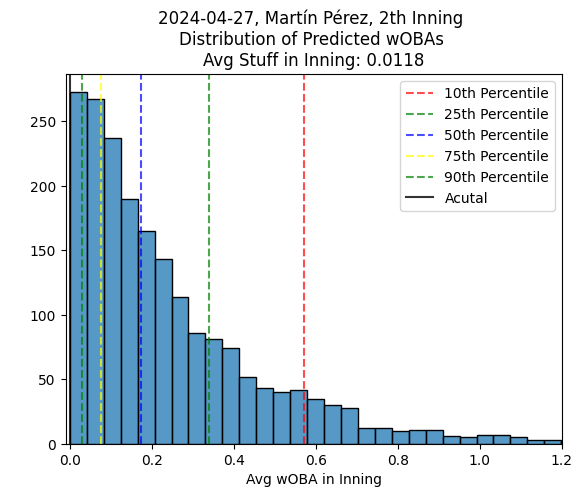

In [ ]:
inning_pred_distribution_exp_hlm(date="2024-04-27", inning = 2, pitcher = 527048)

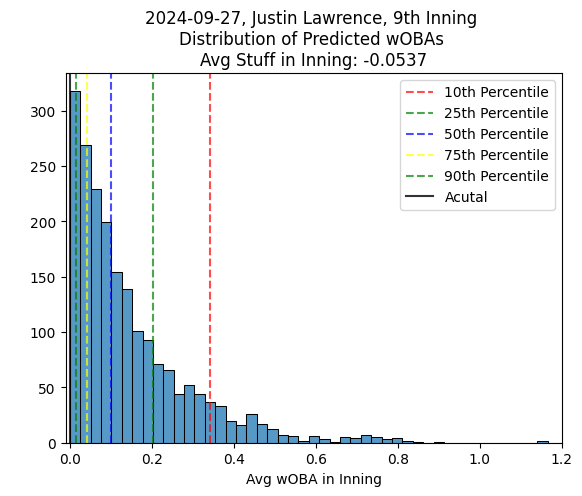

In [ ]:
inning_pred_distribution_exp_hlm(date="2024-09-27", inning = 9, pitcher = 664875)

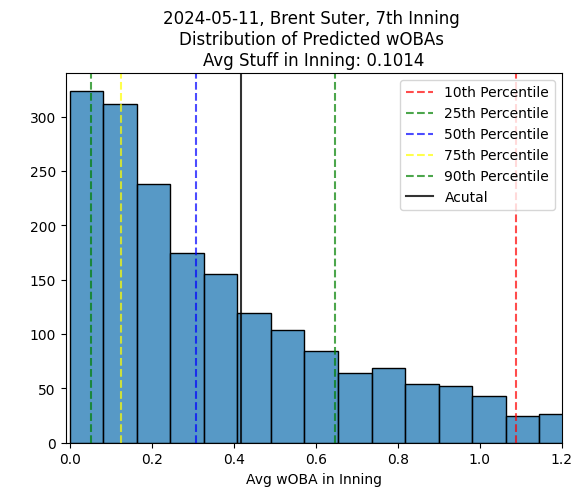

In [ ]:
inning_pred_distribution_exp_hlm(date="2024-05-11", inning = 7, pitcher = 608718)